# Hawkes-process JSCC — real spike train in/out, random N

Continuation of `point_process_jscc.ipynb`, same assignment (`student_project_point_process_jscc.pdf`),
same Gaussian jitter channel, same constraint `N_X = N_S`, `R = 1`. SNN version "in the
classical sense" of the term, after discussion on the architecture:

1. **The source**: a Hawkes process with an exponential kernel, observed over a **fixed**
   window `Ts`, with no event count imposed a priori. A real point process has a
   **random** number of events over a fixed window — the PDF's `N_X = N_S` constraint should
   therefore not be a property of the source, but a **structural** constraint imposed by
   the encoder, block by block.
2. **The SNN's input/output is a real spike train**: a binary raster over `T_bins`
   fixed discrete time steps, not analog features derived per event. Still a
   single hidden LIF layer, feed-forward.
3. **`N_X = N_S` is guaranteed by construction (top-N by rank)**, not by a loss penalty:
   true for any weights, even before training.
4. **The distortion faithfully follows eq. 7-8 of the PDF** (`(1/N)Σ(T_i-T̂_i)²`, matched by index,
   continuous) rather than a bin-by-bin MSE on the raster -- cf. markdown "Distortion faithful to the PDF".

## Two gradient bugs found and fixed along the way

While digging into why the encoder was learning almost nothing, two breaks in the computation graph:

- **The channel was cutting off all gradient to the encoder** (`r_channel.requires_grad` was `False`,
  `encoder.net.syn.weight.grad` was `None`) -- `.bool()`, `.floor()`, `scatter_` with a
  constant value carry no gradient. Fixed via straight-through (exact forward, differentiable
  Gaussian kernel backward). Cf. markdown "Channel".
- **The threshold `theta` of each LIF neuron received no gradient** (`theta.grad` was
  `None`) once the readout was based on `u` rather than `s`: `theta` only influences `s`, detached
  in the reset term. Fixed by no longer detaching `s` (1st SuperSpike approximation). Cf.
  markdown "The simple SNN".

**These fixes alone are not enough to get a well-trained system**: even
after both, `decoder` and `jscc` remain clearly worse than `uncoded` on the training budget
tested. The PDF explicitly anticipates this risk ("Optimization issue: be careful
about possible optimization issues") -- cf. "Limitations" at the end of the notebook for details on the
probable causes (presented here as an acknowledged research finding, not a hidden confusion).

## Accepted limitation: temporal quantization and bin collisions

Going back to a raster with fixed `T_bins` reintroduces the discretization that an earlier version of
this notebook deliberately avoided (the times `T_i` in the PDF are continuous). Empirically measured
consequence: the Hawkes source has a non-negligible proportion of very small gaps, so
**even at `T_bins=1024`, a significant fraction of blocks has at least two events in the
same bin** (collision, merged into a single `1`, information loss). `T_bins=128` is a
compromise adopted here, not a point where the problem disappears.

In [1]:
from __future__ import annotations  # `X | None` in annotations, even on Python 3.9

from dataclasses import dataclass, replace
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)
DEVICE = "cpu"


@dataclass
class Config:
    # ---------------- source (Hawkes, real point process, random N) --------
    Ts: float = 1.0             # source block duration (FIXED window). Tc = Ts, R = 1.
    mean_gap: float = 1.0 / 9.0 # time scale of the source (mu, alpha, beta and
                                 # sigma_J depend on it). N_S per block is RANDOM,
                                 # this field only sets a mean rate, not a count.
    hawkes_branching: float = 0.5   # n = alpha/beta in (0,1): share of the rate
                                     # coming from self-excitation. n->0: near-Poisson.
    hawkes_decay: float = 1.0       # lifetime of the excitation, units of mean gap.
    n_burn: int = 100           # burn-in events before recording (stationarity).
    max_events_cap: int = 400   # technical safeguard (near-critical branching) --
                                 # never reached in practice over the grid studied.

    # ---------------- representation: binary raster (the SNN's "time") -----
    T_bins: int = 128           # number of fixed time bins. Fidelity/cost
                                 # tradeoff -- cf. markdown, nonzero collisions
                                 # even at much larger T_bins.

    # ---------------- channel ---------------------------------------------------
    sigma_J: float = 0.03       # jitter standard deviation (units of Ts).

    # ---------------- network (SNN) ---------------------------------------------
    hidden: int = 64            # width of the single hidden LIF layer.
    spike_alpha: float = 2.0    # arctan surrogate slope (LIF spikes and top-N).

    # ---------------- optimization ------------------------------------------------
    steps: int = 3000
    batch: int = 256
    lr: float = 3e-4            # lr=3e-3 (initial value) makes this loss diverge:
                                 # good early on (~step 150), then explodes to a
                                 # plateau 5-15x worse. 3e-4 stays stable (cf. markdown
                                 # "Distortion faithful to the PDF").
    seed: int = 0
    eval_batch: int = 8000

    @property
    def Tc(self) -> float:
        return self.Ts                      # R = Ts/Tc = 1

    @property
    def bin_width(self) -> float:
        return self.Ts / self.T_bins


CFG = Config()
print(CFG)
print(f"bin_width = {CFG.bin_width:.5f}  (mean_gap = {CFG.mean_gap:.4f})")

Config(Ts=1.0, mean_gap=0.1111111111111111, hawkes_branching=0.5, hawkes_decay=1.0, n_burn=100, max_events_cap=400, T_bins=128, sigma_J=0.03, hidden=64, spike_alpha=2.0, steps=3000, batch=256, lr=0.0003, seed=0, eval_batch=8000)
bin_width = 0.00781  (mean_gap = 0.1111)


## Runtime constants

In [2]:
BRANCHING_GRID = [0.0, 0.3, 0.6, 0.85]   # 0.0 = near-Poisson, memoryless control
SIGMA_RATIO = 0.4                         # sigma_J / mean_gap, fixed for the whole sweep
MODES = ["uncoded", "decoder", "jscc"]

RASTER_N_BLOCKS, RASTER_SEED = 16, 3
GAPMAP_N_BLOCKS, GAPMAP_SEED = 1500, 4242
REALISATION_BLOCKS, REALISATION_SEED = [0, 1, 2, 3, 4], 7   # several blocks, variable N_S

## Plotting conventions

Same palette and same `style` function as `point_process_jscc.ipynb` (itself aligned with
`temporal-jscc/scripts/visualize.py`), so the three notebooks read together.

In [3]:
C_UNCODED, C_DECODER, C_JSCC = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#8a8983", "#e4e3df", "#fcfcfb"
MODE_STYLE = {"uncoded": (C_UNCODED, "o"), "decoder": (C_DECODER, "s"),
              "jscc": (C_JSCC, "^")}


def style(ax, xlabel, ylabel, title, subtitle=None):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK2, labelsize=9, length=3, color=GRID)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10)
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=26 if subtitle else 8)
    if subtitle:
        ax.text(0.0, 1.02, subtitle, transform=ax.transAxes, color=MUTED,
                fontsize=9, va="bottom")


def legend(ax, loc="upper left"):
    leg = ax.legend(frameon=False, fontsize=9, loc=loc)
    for t in leg.get_texts():
        t.set_color(INK2)

## Source: Hawkes with an exponential kernel, fixed window, random N

```
lambda(t) = mu + alpha * sum_{T_i < t} exp(-beta * (t - T_i))
```

each event temporarily raises the intensity, so points arrive in bursts followed
by silences. `mu`, `alpha`, `beta` are derived from `mean_gap`, `hawkes_branching`
(`n = alpha/beta`) and `hawkes_decay`, so that the mean equilibrium rate stays `1/mean_gap`.
Simulated exactly via Ogata's (1981) thinning, with a burn-in to start in the
stationary regime.

**Difference from an earlier version of this notebook**: here, we don't accumulate up to a
fixed number of events and then renormalize the block. We simulate over `[0, Ts)` (fixed
window) and keep every event that falls within it, whatever their number — a real point
process. The result is directly rasterized: `r_source ∈ {0,1}^{T_bins}`, `1` if an event
falls in that bin. `N_S = r_source.sum()` is a **consequence** of the draw, never a parameter.

In [4]:
def _hawkes_window_record(mu, alpha, beta, n_burn, Ts, max_events, rng):
    """One Hawkes block via Ogata's (1981) thinning, over a FIXED window of
    duration Ts -- N_S is a consequence of the draw, not a parameter fixed
    a priori. `n_burn` events are simulated and discarded before anything is
    recorded, to start in the stationary regime rather than with
    `excess = 0`. We stop as soon as the next candidate time exceeds Ts:
    since this time only grows as thinning proceeds, no
    accepted event can fall back under Ts afterwards. `max_events` is
    a technical safeguard (near-critical branching), not a constraint on N.
    """
    t, excess = 0.0, 0.0
    for _ in range(n_burn):
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        if rng.random() <= (mu + excess) / M:
            excess += alpha
    t0 = t

    times = []
    while len(times) < max_events:
        M = mu + excess
        tau = rng.exponential(1.0 / M)
        excess *= np.exp(-beta * tau)
        t += tau
        t_rel = t - t0
        if t_rel >= Ts:
            break
        if rng.random() <= (mu + excess) / M:
            times.append(t_rel)
            excess += alpha
    return np.array(times)


def sample_source(cfg: Config, batch: int, rng: np.random.Generator):
    """-> (r_source (batch, T_bins), n_raw (batch,)).

    r_source: binary raster, 1 if an event falls in that bin. n_raw: the
    number of RAW events simulated (before rasterization) -- used only
    for collision diagnostics (n_raw != r_source.sum(dim=1) when two
    events fell in the same bin).
    """
    lam0 = 1.0 / cfg.mean_gap
    n = float(cfg.hawkes_branching)
    beta = 1.0 / (cfg.hawkes_decay * cfg.mean_gap)
    alpha = n * beta
    mu = lam0 * (1.0 - n)
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        times = _hawkes_window_record(mu, alpha, beta, cfg.n_burn, cfg.Ts,
                                       cfg.max_events_cap, rng)
        n_raw[b] = len(times)
        if len(times):
            idx = np.minimum((times / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def raster_to_times(r: torch.Tensor, cfg: Config):
    """(B,T_bins) raster -> list of B time arrays (bin centers),
    increasing by construction (bin index order). Used only
    for diagnostics/figures, not the training path."""
    centers = (torch.arange(cfg.T_bins, dtype=torch.float32) + 0.5) * cfg.bin_width
    return [centers[row.bool()].numpy() for row in r]


def source_stats(cfg: Config, batch: int = 4000, seed: int = 12345) -> dict:
    r, n_raw = sample_source(cfg, batch, np.random.default_rng(seed))
    n_s = r.sum(dim=1).numpy()
    return {"mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((n_raw != n_s).mean()),
            "frac_capped": float((n_raw >= cfg.max_events_cap).mean())}


for b in BRANCHING_GRID:
    print(f"branching={b:4.2f}  {source_stats(replace(CFG, hawkes_branching=b))}")

branching=0.00  {'mean_n_s': 8.687749862670898, 'std_n_s': 2.8192641735076904, 'frac_source_collision': 0.26675, 'frac_capped': 0.0}


branching=0.30  {'mean_n_s': 8.967499732971191, 'std_n_s': 3.8187620639801025, 'frac_source_collision': 0.341, 'frac_capped': 0.0}


branching=0.60  {'mean_n_s': 10.148750305175781, 'std_n_s': 6.639286518096924, 'frac_source_collision': 0.4325, 'frac_capped': 0.0}


branching=0.85  {'mean_n_s': 17.364500045776367, 'std_n_s': 16.575769424438477, 'frac_source_collision': 0.57775, 'frac_capped': 0.0}


`mean_n_s` grows a bit with `branching` (self-excitation pushes more events into the
window), and especially `frac_source_collision` (fraction of blocks where at least two events
fell in the same bin) increases markedly with `branching`: this is the signature of bursts —
intra-burst gaps smaller than `bin_width`, hence more collisions. `frac_capped` should
stay at 0: otherwise `max_events_cap` is too low for this regime.

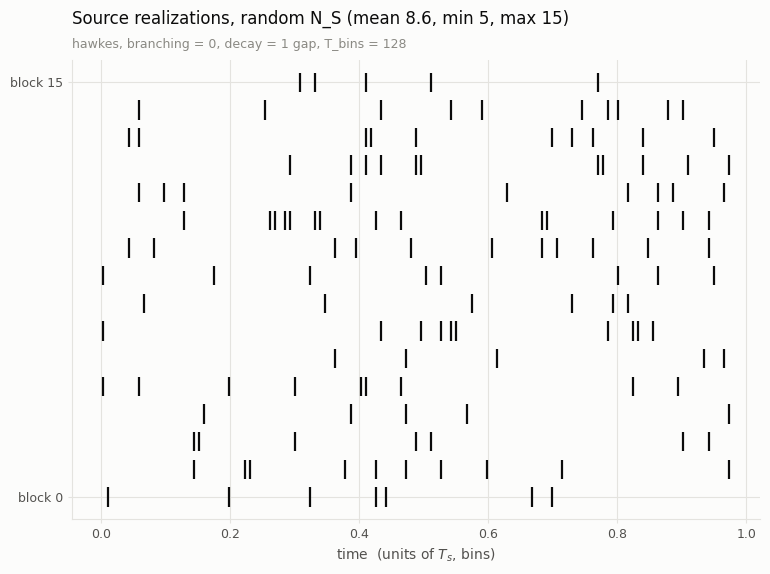

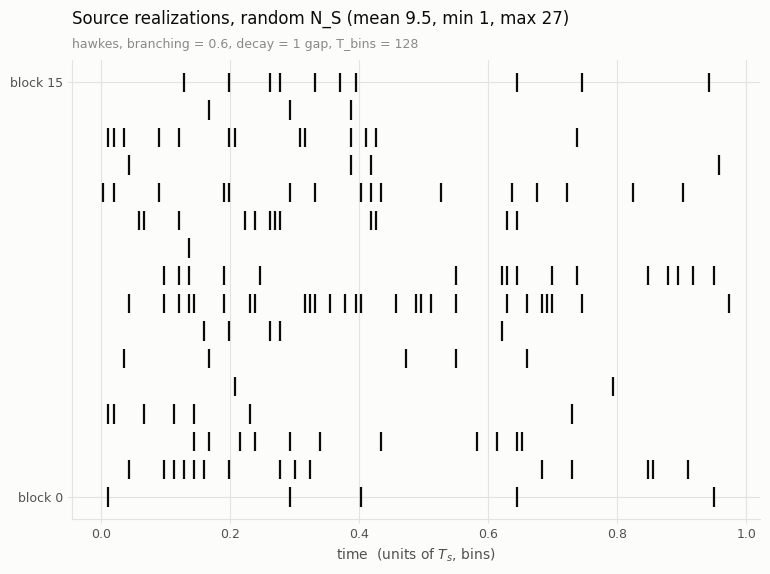

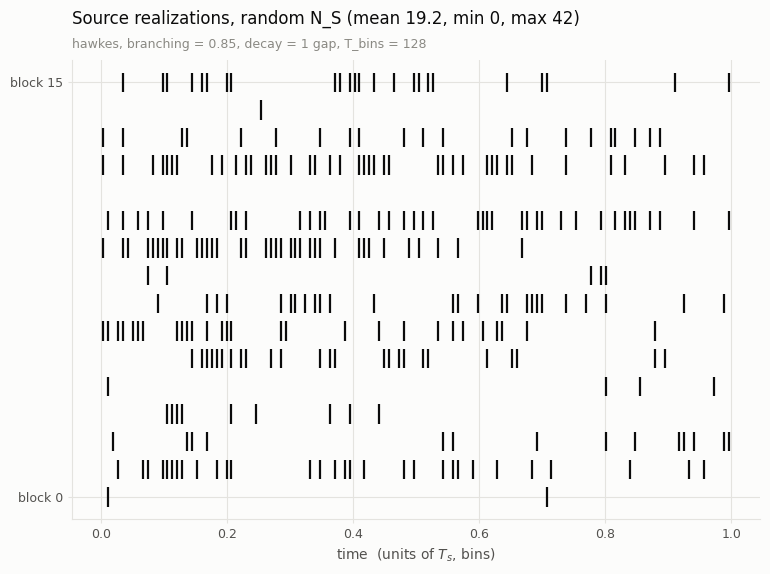

In [5]:
def fig_source_raster(cfg: Config, n_blocks: int = 16, seed: int = 3):
    r, _ = sample_source(cfg, n_blocks, np.random.default_rng(seed))
    times = raster_to_times(r, cfg)
    n_s = [len(t) for t in times]
    fig, ax = plt.subplots(figsize=(7.8, 0.24 * n_blocks + 2.0), facecolor=SURFACE)
    ax.eventplot(times, colors=INK, lineoffsets=np.arange(n_blocks),
                 linelengths=0.7, linewidths=1.6, zorder=5)
    ax.set_ylim(-0.8, n_blocks - 0.2)
    ax.set_yticks([0, n_blocks - 1])
    ax.set_yticklabels(["block 0", f"block {n_blocks - 1}"])
    style(ax, "time  (units of $T_s$, bins)", "",
          f"Source realizations, random N_S (mean {np.mean(n_s):.1f}, "
          f"min {min(n_s)}, max {max(n_s)})",
          f"hawkes, branching = {cfg.hawkes_branching:g}, decay = {cfg.hawkes_decay:g} gap, "
          f"T_bins = {cfg.T_bins}")
    fig.tight_layout()
    return fig


for b in (0.0, 0.6, 0.85):
    fig_source_raster(replace(CFG, hawkes_branching=b), n_blocks=RASTER_N_BLOCKS,
                      seed=RASTER_SEED)
    plt.show()

## Channel

Additive Gaussian jitter, applied to a spike raster rather than continuous times.

**Bug found and fixed: the channel was cutting off all gradient to the encoder.** The initial
version built the output raster via `.bool()`, `.floor()`, `.long()` and `scatter_` with a
*constant* value (`torch.ones_like(r)`, not `r` itself) -- none of these operations
carry a gradient. Verified result: `r_channel.requires_grad` was `False`, and
`encoder.net.syn.weight.grad` was `None` after `backward()` -- the encoder received
**literally no error signal**, no matter how long it was trained. This is not a
noise-scale or learning-rate issue: the gradient path was broken.

**Fix**: the same straight-through principle as everywhere else in this notebook. Forward,
the behavior stays *exactly* the same exact re-binning (bit-for-bit identical, verified). Backward,
a differentiable Gaussian kernel redistributes each source spike toward the output bins
near its jittered time (`softmax` over the distance to the jittered time), weighted by `r`
itself -- so `r` (the encoder's output) now genuinely influences the channel's output
from the gradient's point of view, without changing the exact observed semantics.

In [6]:
def channel(r: torch.Tensor, sigma: float, cfg: Config,
            gen: torch.Generator | None = None) -> torch.Tensor:
    """(B,T_bins) raster -> (B,T_bins) noisy raster. Straight-through:
    - forward, EXACT re-binning (identical to the previous version, bit-for-bit):
      continuous Gaussian noise on bin centers, then re-rasterization via a
      "dustbin" (index T_bins) that absorbs zero positions.
    - backward, a Gaussian kernel (`softmax` over the distance to the noisy time of
      each source bin) differentiably redistributes the mass of `r` toward the
      output bins -- without this, `r_channel.requires_grad` is `False` and
      the encoder never receives any gradient (bug found while testing, cf.
      markdown). A collision (two 1s into the same bin) merges into a single 1,
      as before (cf. frac_channel_collision)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    z = torch.randn(B, T, generator=gen, device=r.device) * sigma
    jittered = centers.unsqueeze(0) + z

    new_idx = (jittered / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(r.bool(), new_idx, torch.full_like(new_idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=r.device, dtype=r.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(r))
    hard = r_ext[:, :T]

    kernel_bw = cfg.bin_width
    diff = centers.view(1, 1, T) - jittered.unsqueeze(2)          # (B, T_src, T_out)
    kernel = torch.softmax(-diff ** 2 / (2 * kernel_bw ** 2), dim=-1)
    soft = torch.einsum("bs,bso->bo", r, kernel)

    return hard.detach() + soft - soft.detach()

## The simple SNN

A single spiking ingredient: the LIF (leaky integrate-and-fire) cell, hard threshold forward
(Heaviside), arctan surrogate gradient backward (Neftci, Mostafa & Zenke). The input **is** the
spike train itself: a binary raster `(B, T_bins)`, 1 bit per time step, no derived
analog feature. Still **a single hidden layer**, feed-forward (no learned recurrent
weight): memory from one step to the next comes only from the membrane potential's leak.

**Reading the potential `u` rather than the spike `s` at the output.** With sparse binary input,
reading `head(s)` produces an identical value for all bins of initial silence (before the
first real spike, `u` stays at its fixed point 0). Reading `u` (continuous) avoids this collapse.

**Second bug found and fixed: `theta` (the per-neuron threshold) received no gradient.**
Direct consequence of the previous point: once the output is based on `u` rather than `s`, `s`
only enters the reset term `(1 - s.detach())` -- deliberately detached
(2nd SuperSpike approximation). But `theta` only influences `s` (`spike(u - theta)`), never
`u` directly. With `s` detached at its only other use, `theta` ended up totally
disconnected from the computation graph: `theta.grad` was `None`, not just zero -- a dead
parameter, never learned, no matter how much training. Fix: stop detaching `s` in the reset
(1st SuperSpike approximation, simpler) -- verified, `theta.grad` is now nonzero.

**Output constraint "same number of spikes as input" (top-N), not a loss penalty.**
After unrolling over the `T_bins` steps, we select exactly the `n` highest-scoring bins
(`n` = number of input spikes) **by rank** (`argsort`), not by comparing values
to a threshold (numerically fragile, cf. code). Structural guarantee -- true for any weights,
even before training.

In [7]:
class ATanSpike(torch.autograd.Function):
    """Heaviside forward, arctan surrogate backward (Neftci, Mostafa & Zenke)."""

    @staticmethod
    def forward(ctx, u, alpha):
        ctx.save_for_backward(u)
        ctx.alpha = alpha
        return (u > 0).to(u.dtype)

    @staticmethod
    def backward(ctx, grad_out):
        (u,) = ctx.saved_tensors
        a = ctx.alpha
        return grad_out * a / (2 * (1 + (torch.pi / 2 * a * u) ** 2)), None


def spike(u, alpha: float = 2.0):
    return ATanSpike.apply(u, alpha)


def _topn_tau(raw: torch.Tensor, n: torch.Tensor) -> torch.Tensor:
    """(B,T) scores, (B,) target count -> (B,) threshold = n-th largest value
    of raw (0 if n=0 -> threshold +inf, no spike passes). Treated as a
    constant (`.detach()`) everywhere it is used: it's a threshold, not a
    learned parameter."""
    sorted_vals, _ = raw.sort(dim=1, descending=True)
    k_idx = (n.long() - 1).clamp(min=0)
    tau = torch.gather(sorted_vals, 1, k_idx.unsqueeze(1)).squeeze(1).detach()
    return torch.where(n > 0, tau, torch.full_like(tau, float("inf")))


def topn_spike(raw: torch.Tensor, n: torch.Tensor, alpha: float = 2.0) -> torch.Tensor:
    """(B,T) scores, (B,) target count n -> (B,T) raster with EXACTLY n bits
    set to 1 per row (0 if n=0). The "output = n" constraint is structural, true
    for any weights, even before training.

    Selection forward BY RANK (argsort, stable sort) rather than by comparing
    values to a threshold: a value comparison (`raw > tau`) turned out to be
    numerically fragile in practice -- exact ties at the start of a block
    (initial silence, `u` at its fixed point), then a fixed-scale correction
    offset that becomes insufficient once the network is
    trained (large-magnitude scores, insufficient floating-point precision;
    measured: up to ~2-3% of blocks disagreeing). Rank, on the other hand, is exact regardless
    of the magnitude or ties in `raw` (verified 100% exact, including
    with scores ~1e5 or total ties).

    The gradient stays smooth: a "soft" version (same Heaviside + arctan
    surrogate as the LIF cell, thresholded at `_topn_tau`) carries the gradient by
    straight-through (`hard.detach() + soft - soft.detach()`).
    """
    B, T = raw.shape
    tau = _topn_tau(raw, n)
    order = raw.argsort(dim=1, descending=True)
    rank = torch.empty_like(order)
    rank.scatter_(1, order, torch.arange(T, device=raw.device).unsqueeze(0).expand(B, T))
    hard = (rank < n.long().unsqueeze(1)).to(raw.dtype)
    soft = spike(raw - tau.unsqueeze(1), alpha)
    return hard.detach() + soft - soft.detach()


class LIFCell(nn.Module):
    """u_t = beta * u_{t-1} * (1 - s_{t-1}) + I_t ; s_t = H(u_t - theta).

    beta (leak) and theta (threshold) are learned, per unit. The reset factor
    `(1 - s_{t-1})` is **not** detached (1st SuperSpike approximation):
    detaching `s` here cut off all gradient to `theta` once the readout was based
    on `u` rather than `s` (`theta` only influences `s`, never `u` directly) --
    bug found while testing (`theta.grad` was `None`), fixed here.
    """

    def __init__(self, n_units: int, beta: float = 0.9, theta: float = 1.0, alpha: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.beta_logit = nn.Parameter(torch.logit(torch.full((n_units,), beta)))
        self.theta = nn.Parameter(torch.full((n_units,), theta))

    def forward(self, current, u, s):
        beta = torch.sigmoid(self.beta_logit)
        if u is None:
            u = torch.zeros_like(current)
            s = torch.zeros_like(current)
        u = beta * u * (1.0 - s) + current
        s = spike(u - self.theta, self.alpha)
        return s, u, s


class SimpleSNN(nn.Module):
    """The whole architecture -- encoder and decoder share this class: a
    linear synapse into an LIF layer, unrolled over the T_bins steps of the
    raster (in order), then a linear readout of the membrane potential
    at each step. Nothing more -- no extra layer, no learned
    recurrence. `n_in=1`: the input is the spike bit itself.
    """

    def __init__(self, cfg: Config, n_in: int = 1, beta: float = 0.9):
        super().__init__()
        self.cfg = cfg
        self.in_norm = nn.LayerNorm(n_in) if n_in > 1 else nn.Identity()
        self.syn = nn.Linear(n_in, cfg.hidden, bias=False)
        self.lif = LIFCell(cfg.hidden, beta=beta)
        self.head = nn.Linear(cfg.hidden, 1)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        """feats: (B, T_bins, n_in) -> (B, T_bins), one real score per bin."""
        u, s = None, None
        outs = []
        for i in range(feats.shape[1]):
            current = self.syn(self.in_norm(feats[:, i]))
            s, u, _ = self.lif(current, u, s)
            outs.append(self.head(u).squeeze(-1))  # reads u (continuous), not s -- cf. markdown
        return torch.stack(outs, dim=1)

In [8]:
class Encoder(nn.Module):
    """SNN with spikes in/out. N_X = N_S guaranteed by construction
    (topn_spike), never learned."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor) -> torch.Tensor:
        raw = self.net(r_source.unsqueeze(-1))
        n = r_source.sum(dim=1)
        return topn_spike(raw, n, self.cfg.spike_alpha)


class Decoder(nn.Module):
    """Same principle: the output has exactly as many spikes as what the
    decoder receives as input (not necessarily N_S if the channel merged
    two spikes into the same bin -- cf. frac_channel_collision). Also exposes
    `raw`/`tau` (the per-bin score and the top-N threshold): needed for the
    distortion faithful to the PDF (next section), which needs a
    differentiable estimate of the *time* of each reconstructed spike, not just the
    final raster."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_channel: torch.Tensor):
        raw = self.net(r_channel.unsqueeze(-1))
        n = r_channel.sum(dim=1)
        tau = _topn_tau(raw, n)
        r_hat = topn_spike(raw, n, self.cfg.spike_alpha)
        return r_hat, raw, tau


class System(nn.Module):
    """mode: "uncoded" (no parameters) | "decoder" | "jscc"."""

    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = Encoder(cfg) if mode == "jscc" else None
        self.decoder = Decoder(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        r_code = r_source if self.encoder is None else self.encoder(r_source)
        r_channel = channel(r_code, sigma, self.cfg, gen)
        if self.decoder is None:
            r_hat, raw_dec, tau_dec = r_channel, None, None
        else:
            r_hat, raw_dec, tau_dec = self.decoder(r_channel)
        return {"r_hat": r_hat, "r_code": r_code, "r_channel": r_channel,
                "raw_dec": raw_dec, "tau_dec": tau_dec}

    @property
    def n_params(self) -> int:
        return sum(p.numel() for p in self.parameters())

## Distortion faithful to the PDF

The PDF (eq. 7-8) defines the distortion as a **continuous, index-matched** MSE:
`d(S, Ŝ) = (1/N) Σ (T_i - T̂_i)²`. An MSE computed directly on the raster (bin by bin, 0/1)
is **not** this formula: it treats "1 bin off" and "50 bins off" identically
(no partial credit for "being close"), whereas `(T_i-T̂_i)²` naturally gives one. Observed
empirically: under the raster MSE, the JSCC encoder learned a degenerate strategy (clustering
its spikes into a narrow zone of the raster, which *increased* the channel collision rate
from ~25-40% to ~80-90% regardless of the noise or `T_bins`) -- a shortcut that the PDF's real
distortion, which tracks each event's identity, does not allow.

**Differentiable computation of `T̂_i` from the raster.** The decoder produces a continuous score per
bin (`raw`) and a top-N threshold (`tau`). To associate each bin with a "temporal rank" (being
the 1st, 2nd, ... event of the block), we use a cumulative sum of the selection mask:
`c[t] = cumsum(p)[t] - 0.5*p[t]`, where `p` is a selection indicator. A truly
selected bin sees `c` equal `(its rank) + 0.5` -- we therefore compare `c` to `rank + 0.5` with a
narrow Gaussian kernel to get a per-bin assignment weight, then take the weighted average of
bin centers as the estimate of `T̂_i`.

**Numerical trap found while testing**: `tau` is *by definition* the value of the boundary bin (the
`n`-th largest score), so `sigmoid(raw - tau)` equals **exactly 0.5** for that bin, never
close to 1 -- even with very well-separated scores elsewhere. Using this soft indicator
directly for `p` systematically undercounts by 0.5 the rank of every subsequent event
in the block (verified: position error ~1 whole block, far larger than `bin_width`).
Fix: `p` uses the same straight-through as `topn_spike` (exact mask by rank
forward, smoothed gradient backward) -- the error then drops below 1% of a bin.

**Collisions and matching.** The channel can merge two spikes into the same bin, giving
`N_Ŝ < N_S` for that block -- the `N_X=N_S` assumption of eq. 7 then no longer holds exactly.
Convention adopted: only match the first `min(N_S, N_Ŝ)` events (in chronological order),
normalized by that count.

In [9]:
def exact_rank_times(r: torch.Tensor, cfg: Config, N_max: int):
    """(B,T_bins) EXACT raster (0/1) -> (t (B,N_max), mask (B,N_max)): times
    of the selected bins in increasing order, exact (no gradient required,
    used for the SOURCE times, constant, and for eval metrics)."""
    B, T = r.shape
    centers = (torch.arange(T, device=r.device, dtype=r.dtype) + 0.5) * cfg.bin_width
    cum = torch.cumsum(r, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=r.dtype)
    mask_ext = torch.zeros(B, N_max + 1, device=r.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, centers.unsqueeze(0).expand(B, T))
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def rank_times(raw: torch.Tensor, tau: torch.Tensor, cfg: Config, N_max: int,
               alpha: float, temp_rank: float = 0.3) -> torch.Tensor:
    """(B,T_bins) scores + top-N threshold -> (B,N_max) DIFFERENTIABLE estimate of
    the time of each temporal rank (0-indexed). `p` (indicator "this bin is
    selected") uses the same straight-through as `topn_spike`: EXACT mask
    (`raw >= tau`, exactly n bins set to 1 since tau is the n-th
    largest value) forward, smooth sigmoid backward -- cf. markdown for the
    trap avoided (sigmoid(raw-tau) is exactly 0.5 at the boundary bin, which
    undercounts the rank of every subsequent event if used as-is forward)."""
    B, T = raw.shape
    centers = (torch.arange(T, device=raw.device, dtype=raw.dtype) + 0.5) * cfg.bin_width
    soft_sig = torch.sigmoid(alpha * (raw - tau.unsqueeze(1)))
    hard_sel = (raw >= tau.unsqueeze(1)).to(raw.dtype)
    p = hard_sel.detach() + soft_sig - soft_sig.detach()
    c = torch.cumsum(p, dim=1) - 0.5 * p
    ranks = (torch.arange(N_max, device=raw.device, dtype=raw.dtype) + 0.5).view(1, N_max, 1)
    diff = c.view(B, 1, T) - ranks
    w = torch.exp(-diff ** 2 / (2 * temp_rank ** 2)) * p.view(B, 1, T)
    w = w / (w.sum(dim=2, keepdim=True) + 1e-8)
    return (w * centers.view(1, 1, T)).sum(dim=2)


def pdf_distortion(r_source: torch.Tensor, out: dict, cfg: Config, temp_rank: float = 0.3):
    """Distortion faithful to eq. 7-8 of the PDF: (1/N) Σ (T_i - T̂_i)², averaged
    over the batch (= D in eq. 8). Chronological matching up to
    min(N_S, N_channel) (cf. markdown, channel collisions)."""
    n_s = r_source.sum(dim=1)
    n_channel = out["r_channel"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat = rank_times(out["raw_dec"], out["tau_dec"], cfg, N_max, cfg.spike_alpha, temp_rank)
    n_match = torch.minimum(n_s, n_channel)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    sq = (t_true - t_hat) ** 2 * mask_match.float()
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).float()
    return d_block.mean(), d_block, n_match

## Training and measurement

In [10]:
def train_system(cfg: Config, mode: str, verbose: bool = False):
    torch.manual_seed(cfg.seed)
    rng = np.random.default_rng(cfg.seed)
    gen = torch.Generator(device=DEVICE).manual_seed(cfg.seed + 1)
    model = System(cfg, mode).to(DEVICE)
    history = []
    if model.n_params == 0:
        return model, history

    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                total_steps=cfg.steps, pct_start=0.1)
    t0 = time.time()
    for step in range(1, cfg.steps + 1):
        r_source, _ = sample_source(cfg, cfg.batch, rng)
        out = model(r_source, gen=gen)
        loss, _, _ = pdf_distortion(r_source, out, cfg)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()
        if step % max(1, cfg.steps // 6) == 0 or step == cfg.steps:
            history.append({"step": step, "loss": float(loss.detach())})
            if verbose:
                print(f"  {mode:8s} step {step:5d}  loss {float(loss.detach()):.3e}"
                      f"  {time.time() - t0:.0f}s", flush=True)
    return model, history


@torch.no_grad()
def measure(model: System, cfg: Config, seed: int = 99991) -> dict:
    """d_mse here IS the distortion faithful to the PDF (eq. 7-8, units of Ts^2),
    computed exactly (hard raster, not the soft estimate used to
    train): (T_i-T̂_i)^2 matched by chronological index, up to
    min(N_S, N_reconstructed) (cf. markdown "Distortion faithful to the PDF")."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    model.eval()
    r_source, n_raw = sample_source(cfg, cfg.eval_batch, rng)
    out = model(r_source, sigma=cfg.sigma_J, gen=gen)
    n_s = r_source.sum(dim=1)
    n_hat = out["r_hat"].sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    t_true, mask_true = exact_rank_times(r_source, cfg, N_max)
    t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
    n_match = torch.minimum(n_s, n_hat)
    idx = torch.arange(N_max, device=r_source.device).unsqueeze(0)
    mask_match = (idx < n_match.unsqueeze(1)) & mask_true
    block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()

    n_code_ok = (float((out["r_code"].sum(dim=1) == n_s).float().mean())
                 if model.encoder is not None else float("nan"))
    n_hat_ok = (float((out["r_hat"].sum(dim=1) == out["r_channel"].sum(dim=1)).float().mean())
                if model.decoder is not None else float("nan"))
    frac_channel_collision = float((out["r_channel"].sum(dim=1) != out["r_code"].sum(dim=1)).float().mean())
    model.train()
    return {"d_mse": float(block_d.mean()), "median_block_mse": float(block_d.median()),
            "p99_block_mse": float(block_d.quantile(0.99)),
            "mean_n_s": float(n_s.mean()), "std_n_s": float(n_s.std()),
            "frac_source_collision": float((torch.as_tensor(n_raw) != n_s).float().mean()),
            "frac_channel_collision": frac_channel_collision,
            "n_code_matches_n_s": n_code_ok, "n_hat_matches_n_channel": n_hat_ok,
            "sigma_J": cfg.sigma_J, "hawkes_branching": cfg.hawkes_branching,
            "mode": model.mode, "n_params": model.n_params}

## Sweep — does burst intensity change the JSCC gain?

Central question from the PDF (the "Step 2" section, adapted to Hawkes rather than the Gamma
renewal it proposes): the more events are clustered into bursts (high branching), the more
structure there should be for the encoder to exploit -- *if* the system actually learns something
beyond the memoryless source (`branching = 0`, near-Poisson).

`sigma_J` is fixed for the whole sweep, so that any difference between the three systems at
a given `branching` comes from the source, not the channel.

In [11]:
def run_sweep(branching_grid=BRANCHING_GRID, sigma_ratio=SIGMA_RATIO, modes=MODES, verbose=True):
    rows, models = [], {}
    for b in branching_grid:
        cfg = replace(CFG, hawkes_branching=b, sigma_J=sigma_ratio * CFG.mean_gap)
        for mode in modes:
            t0 = time.time()
            model, hist = train_system(cfg, mode)
            m = measure(model, cfg)
            m["train_seconds"] = time.time() - t0
            rows.append(m)
            models[(b, mode)] = (model, cfg, hist)
            if verbose:
                print(f"branching {b:4.2f}  {mode:8s}  d_mse {m['d_mse']:.3e}"
                      f"  mean_n_s {m['mean_n_s']:.1f}"
                      f"  n_code_ok {m['n_code_matches_n_s']}"
                      f"  n_hat_ok {m['n_hat_matches_n_channel']}"
                      f"  ({m['train_seconds']:.0f}s)", flush=True)
    return rows, models


HAWKES_ROWS, HAWKES_MODELS = run_sweep()

branching 0.00  uncoded   d_mse 4.740e-03  mean_n_s 8.7  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.00  decoder   d_mse 3.311e-02  mean_n_s 8.7  n_code_ok nan  n_hat_ok 0.999750018119812  (127s)


branching 0.00  jscc      d_mse 8.261e-02  mean_n_s 8.7  n_code_ok 1.0  n_hat_ok 0.9988750219345093  (177s)


branching 0.30  uncoded   d_mse 5.867e-03  mean_n_s 9.0  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.30  decoder   d_mse 3.291e-02  mean_n_s 9.0  n_code_ok nan  n_hat_ok 0.9983749985694885  (130s)


...

branching 0.60  decoder   d_mse 2.878e-02  mean_n_s 10.2  n_code_ok nan  n_hat_ok 0.996749997138977  (134s)


branching 0.60  jscc      d_mse 6.794e-02  mean_n_s 10.2  n_code_ok 1.0  n_hat_ok 0.9956250190734863  (184s)


branching 0.85  uncoded   d_mse 7.729e-03  mean_n_s 16.9  n_code_ok nan  n_hat_ok nan  (1s)


branching 0.85  decoder   d_mse 2.348e-02  mean_n_s 16.9  n_code_ok nan  n_hat_ok 0.9907500147819519  (150s)


branching 0.85  jscc      d_mse 5.590e-02  mean_n_s 16.9  n_code_ok 1.0  n_hat_ok 0.9908750057220459  (200s)


In [12]:
def show_table(rows, cols=None, title=""):
    cols = cols or ["hawkes_branching", "mode", "d_mse", "median_block_mse",
                    "mean_n_s", "frac_source_collision", "frac_channel_collision",
                    "n_code_matches_n_s", "n_hat_matches_n_channel", "n_params"]
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


show_table(HAWKES_ROWS, title=f"Hawkes, T_bins={CFG.T_bins}, sigma_J/gap = {SIGMA_RATIO:g}")

Hawkes, T_bins=128, sigma_J/gap = 0.4
hawkes_branching |        mode |       d_mse | median_block_mse |    mean_n_s | frac_source_collision | frac_channel_collision | n_code_matches_n_s | n_hat_matches_n_channel |    n_params
-----------------+-------------+-------------+------------------+-------------+-----------------------+------------------------+--------------------+-------------------------+------------
          0.0000 |     uncoded |      0.0047 |           0.0016 |      8.7317 |                0.2606 |                 0.2526 |                nan |                     nan |           0
          0.0000 |     decoder |      0.0331 |           0.0237 |      8.7317 |                0.2606 |                 0.2526 |                nan |                  0.9998 |         257
          0.0000 |        jscc |      0.0826 |           0.0624 |      8.7317 |                0.2606 |                 0.5190 |             1.0000 |                  0.9989 |         514
          0.3000 |    

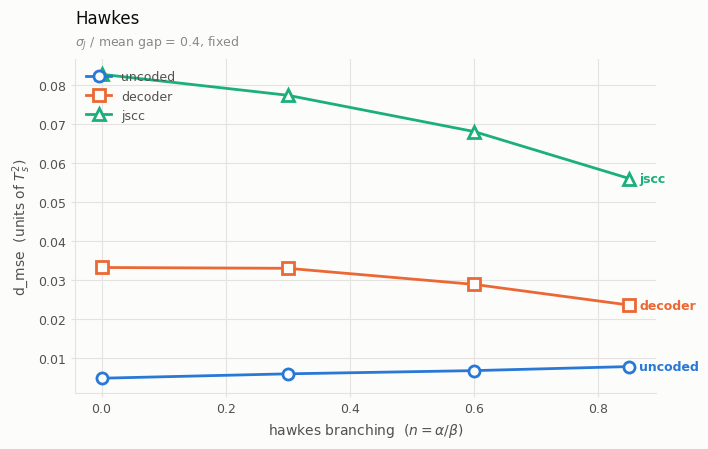

In [13]:
def fig_distortion(rows, metric="d_mse", title="Hawkes"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in MODES:
        pts = sorted([r for r in rows if r["mode"] == mode],
                     key=lambda r: r["hawkes_branching"])
        if not pts:
            continue
        colour, marker = MODE_STYLE[mode]
        xs = [r["hawkes_branching"] for r in pts]
        ys = [r[metric] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
        ax.annotate(mode, (xs[-1], ys[-1]), textcoords="offset points",
                    xytext=(7, 0), color=colour, fontsize=9, fontweight="bold",
                    va="center")
    unit = "$T_s^2$"
    style(ax, "hawkes branching  ($n = \\alpha/\\beta$)", f"{metric}  (units of {unit})",
          title, f"$\\sigma_J$ / mean gap = {SIGMA_RATIO:g}, fixed")
    legend(ax)
    fig.tight_layout()
    return fig


fig_distortion(HAWKES_ROWS)
plt.show()

## Gap mapping (eq. 12) — what does the encoder learn?

For each `branching`, we plot `g_i` (the source gap) against `g_i^{(X)}` (the gap after
encoding): the bin times selected by the encoder, in order. Since `N_X = N_S` is
guaranteed by construction and a raster is ordered by bin index, the `i`-th gap of the code
corresponds to the `i`-th gap of the source for each block (same length on both sides). If
the encoder had converged to identity, all points would lie on the diagonal. We also look
at the factor `g_i^{(X)}/g_i` as a function of the source gap size, to see whether
small gaps (intra-burst) and large gaps (silences) are treated differently.

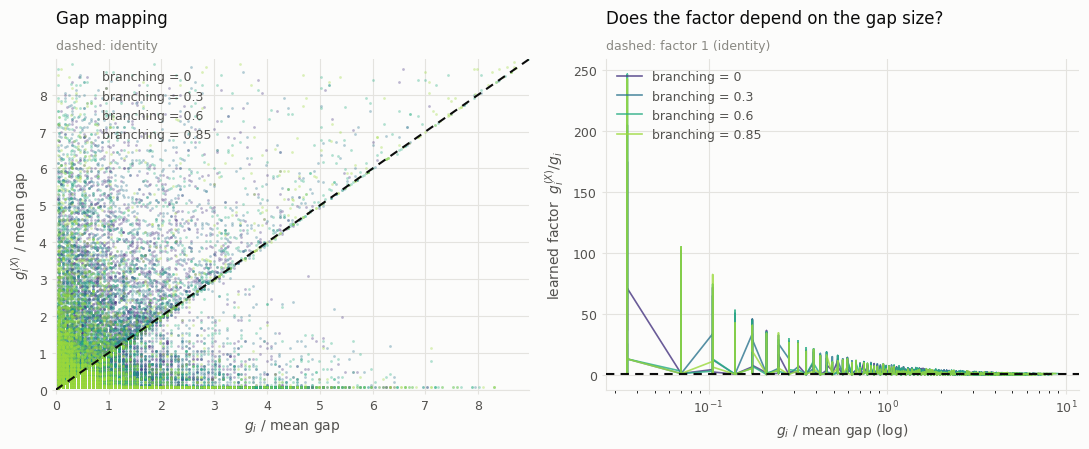

In [14]:
def fig_gap_mapping(models, branchings, n_blocks=GAPMAP_N_BLOCKS, seed=GAPMAP_SEED):
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), facecolor=SURFACE)
    colours = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(branchings)))
    lim = 0.0
    for colour, b in zip(colours, branchings):
        model, cfg, _ = models[(b, "jscc")]
        rng = np.random.default_rng(seed)
        with torch.no_grad():
            r_source, _ = sample_source(cfg, n_blocks, rng)
            r_code = model.encoder(r_source)
        times_s = raster_to_times(r_source, cfg)
        times_x = raster_to_times(r_code, cfg)
        # N_X = N_S guaranteed by construction: same length on both sides,
        # block by block, so the concatenation correctly aligns gap i <-> gap i.
        gs = np.concatenate([np.diff(t, prepend=0.0) for t in times_s]) / cfg.mean_gap
        gx = np.concatenate([np.diff(t, prepend=0.0) for t in times_x]) / cfg.mean_gap
        lim = max(lim, gs.max(initial=0.0), gx.max(initial=0.0))
        axes[0].scatter(gs, gx, s=4, color=colour, alpha=0.35, lw=0,
                        label=f"branching = {b:g}")
        mult = gx / np.clip(gs, 1e-6, None)
        order = np.argsort(gs)
        axes[1].plot(gs[order], mult[order], color=colour, lw=1.2, alpha=0.8,
                     label=f"branching = {b:g}")

    axes[0].plot([0, lim], [0, lim], color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
    style(axes[0], "$g_i$ / mean gap", "$g_i^{(X)}$ / mean gap",
          "Gap mapping", "dashed: identity")
    legend(axes[0])

    axes[1].axhline(1.0, color=INK, lw=1.5, ls=(0, (4, 3)), zorder=4)
    axes[1].set_xscale("log")
    style(axes[1], "$g_i$ / mean gap (log)", "learned factor  $g_i^{(X)} / g_i$",
          "Does the factor depend on the gap size?", "dashed: factor 1 (identity)")
    legend(axes[1])
    fig.tight_layout()
    return fig


fig_gap_mapping(HAWKES_MODELS, [0.0, 0.3, 0.6, 0.85])
plt.show()

## One realization through the chain

Each stage (source, code, channel output, reconstruction) is a raster; we display the bin
times corresponding to the positions set to `1`. Repeated over several blocks to see the
variability of `N_S` (actual number of events) from block to block, since N is no longer fixed
by the source.

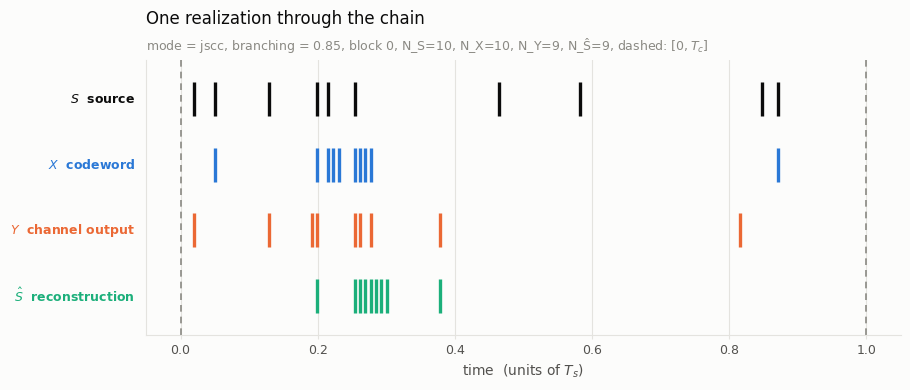

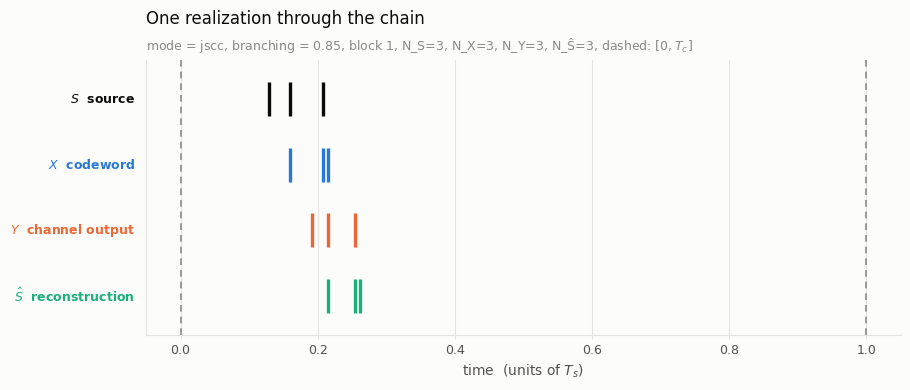

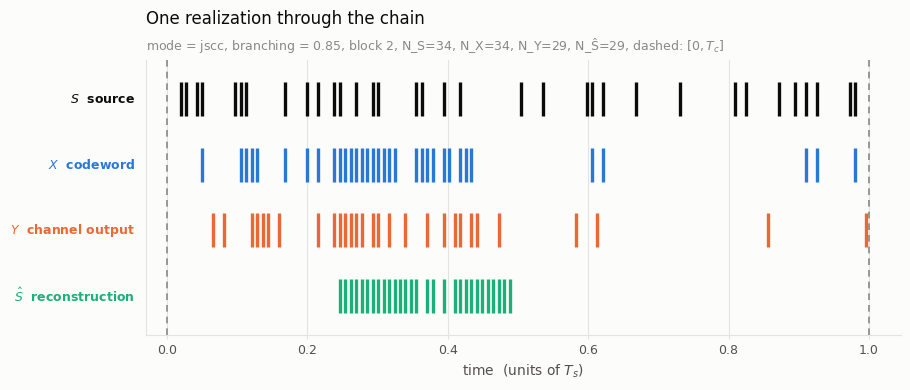

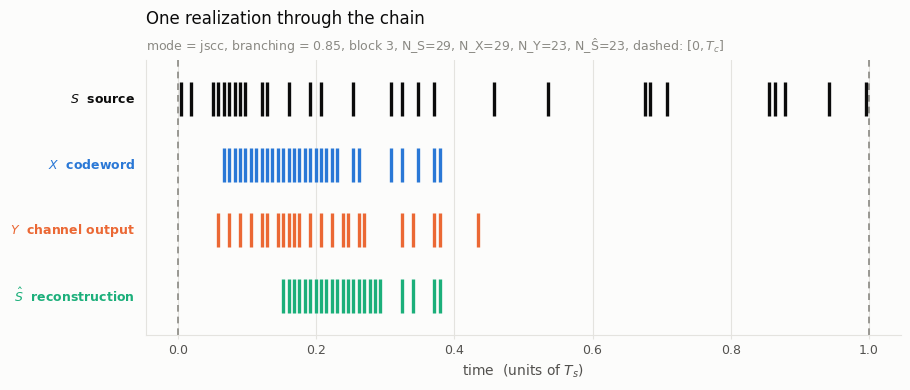

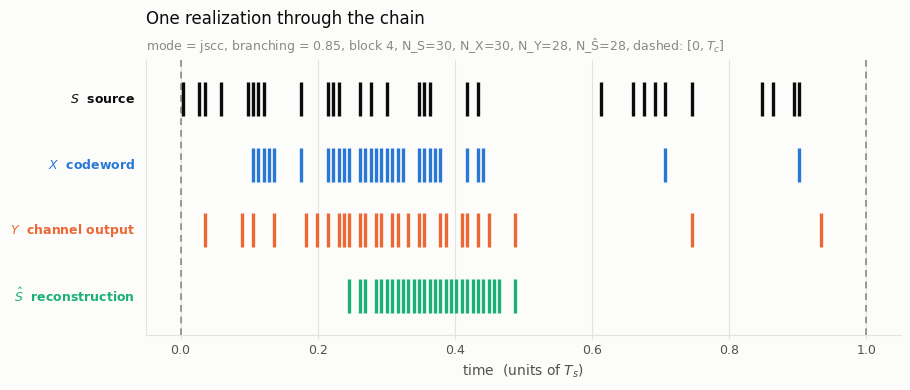

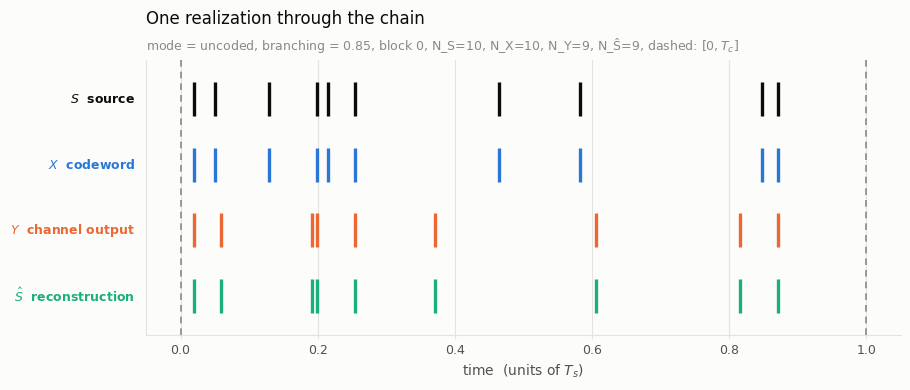

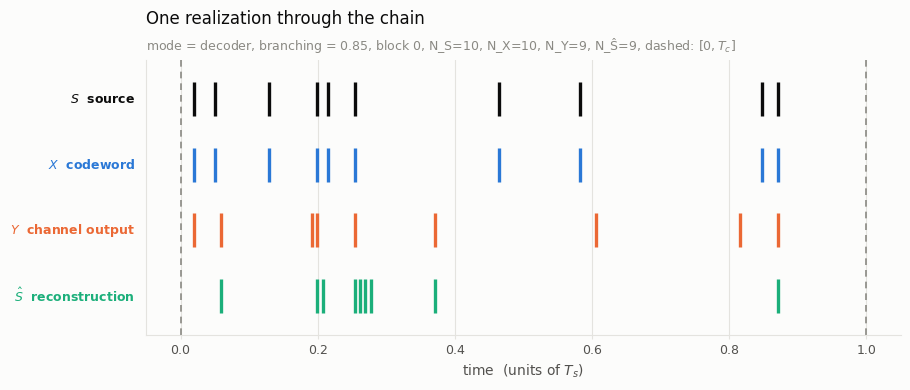

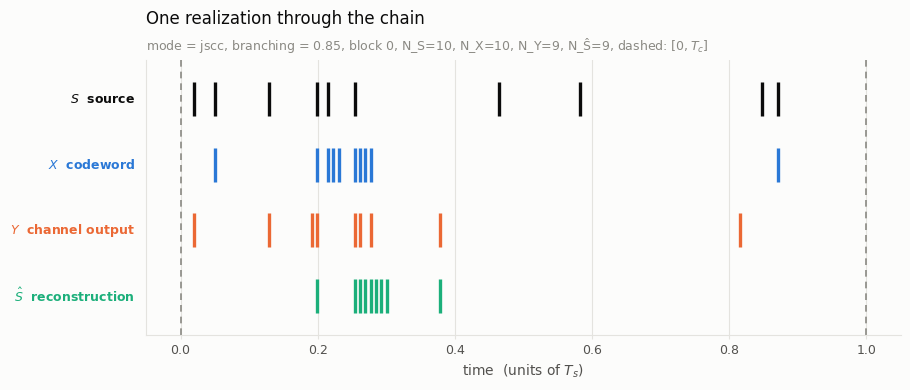

In [15]:
def fig_realisation(models, b, mode="jscc", block=0, seed=REALISATION_SEED):
    model, cfg, _ = models[(b, mode)]
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sample_source(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"mode = {mode}, branching = {b:g}, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, "
           f"dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "", "One realization through the chain", sub)
    fig.tight_layout()
    return fig


for blk in REALISATION_BLOCKS:
    fig_realisation(HAWKES_MODELS, 0.85, mode="jscc", block=blk)
    plt.show()

for m in MODES:
    fig_realisation(HAWKES_MODELS, 0.85, mode=m, block=REALISATION_BLOCKS[0])
    plt.show()

## Limitations and choices made

### Residual optimization difficulty (to discuss with the advisor)

Even after fixing both gradient breaks (channel, LIF threshold) and switching to the
real PDF distortion, `decoder` and `jscc` remain clearly worse than `uncoded` on the budget
tested -- `decoder` alone should nonetheless be able to learn identity and at least match `uncoded`.
Probable, cumulative causes:

1. **Long recurrent unrolling** (`T_bins=128` steps) through a surrogate-gradient network:
   gradients through long recurrent sequences are known to fade/get noisy
   (as with classic RNNs), and the arctan surrogate's approximation error
   accumulates over the 128 steps.
2. **Two stacked top-N mechanisms** (encoder, decoder), each a straight-through
   (hard selection forward, smoothed gradient backward) -- one approximation per mechanism, and
   they combine in series through the channel.
3. **The PDF-faithful distortion adds a third layer of approximation**: the
   soft estimate of `T̂_i` (Gaussian kernel over the cumulative rank, `temp_rank`) has its own
   bias/variance tradeoff -- poorly tuned, it can give a gradient that points in a
   slightly wrong direction (cf. the p=0.5 trap already found and fixed, which shows that this
   kind of silent error is easy to introduce here).
4. **The original learning rate (3e-3, inherited from the continuous version of the notebook) makes
   this loss diverge**: good early on (~step 150), it then explodes to a plateau 5 to
   15x worse. A 10x lower rate (3e-4) stabilizes without fully solving the problem.
5. The PDF explicitly anticipates this kind of difficulty ("Optimization issue: be careful about
   possible optimization issues") -- its "Step 3" section (a minimal two-event model)
   specifically suggests scaling down to the smallest possible scale to isolate the mechanism
   before scaling back up, a natural direction going forward.

### Other accepted limitations

- **Non-negligible bin collisions**, especially in the burst regime (`frac_source_collision` and
  `frac_channel_collision`, tracked in the table): the Hawkes source has a notable proportion
  of gaps smaller than `bin_width`, including at `T_bins` much larger than 128 (measured
  up to `T_bins=1024`, cf. intro markdown). An accepted consequence of switching to a real spike
  raster, not a bug to fix in this notebook.
- **A single seed per point** in the sweep: the gaps between `decoder` and `jscc` should be read with
  this caveat — no error bars here.
- **`sigma_J` fixed** for the whole branching sweep: a cross sweep (branching x sigma) would give
  a more complete picture, but multiplies the cost by the size of the second grid.
- The SNN deliberately remains **a single hidden feed-forward layer** — a simplicity
  choice, not a demonstrated capacity limit.

## Quick comparison between source types (Poisson, Gamma renewal, Hawkes)

The PDF proposes a progression: **Step 1** (Poisson, the most "random" source, where the encoder
could reasonably converge to identity), **Step 2** (renewal, eq. 10:
`W_i ~ Gamma(k, mean_gap/k)`, more predictable as `k` grows), and this notebook's Hawkes
extension (multi-event memory). Exact same pipeline (SNN, channel, top-N, PDF-faithful
distortion) as above, just the source function changes — for a reduced training budget
(`800` steps instead of `3000`, to stay fast): the numbers are therefore indicative, not the
final result of the main sweep.

In [16]:
def sample_poisson(cfg: Config, batch: int, rng: np.random.Generator):
    """Homogeneous Poisson process = i.i.d. exponential renewal
    (PDF, Step 1). Same fixed-window Ts / random N logic as sample_source."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.exponential(cfg.mean_gap)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def sample_gamma_renewal(cfg: Config, batch: int, rng: np.random.Generator, k: float):
    """Gamma renewal, W_i ~ Gamma(k, mean_gap/k) i.i.d. (PDF eq. 10).
    k=1 -> exponential (Poisson); large k -> increasingly regular timing."""
    r = torch.zeros(batch, cfg.T_bins, dtype=torch.float32, device=DEVICE)
    n_raw = np.zeros(batch, dtype=np.int64)
    for b in range(batch):
        t, times = 0.0, []
        while len(times) < cfg.max_events_cap:
            t += rng.gamma(shape=k, scale=cfg.mean_gap / k)
            if t >= cfg.Ts:
                break
            times.append(t)
        n_raw[b] = len(times)
        if times:
            idx = np.minimum((np.array(times) / cfg.bin_width).astype(np.int64), cfg.T_bins - 1)
            r[b, idx] = 1.0
    return r, n_raw


def quick_train_eval(sampler, mode: str, cfg: Config, steps: int = 800, seed: int = 2):
    """Like train_system/measure, but parameterized by the source function
    (sampler(cfg, batch, rng) -> (r, n_raw)) -- same pipeline (SNN, channel,
    top-N, PDF-faithful distortion) as the Hawkes sweep, to quickly compare
    several source types."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed + 1)
    model = System(cfg, mode).to(DEVICE)
    if model.n_params > 0:
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
        sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                    total_steps=steps, pct_start=0.1)
        for step in range(steps):
            r_source, _ = sampler(cfg, cfg.batch, rng)
            out = model(r_source, gen=gen)
            loss, _, _ = pdf_distortion(r_source, out, cfg)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            sched.step()
    with torch.no_grad():
        r_eval, n_raw = sampler(cfg, cfg.eval_batch, np.random.default_rng(9999))
        gen_eval = torch.Generator(device=DEVICE).manual_seed(10000)
        out = model(r_eval, gen=gen_eval)
        n_s = r_eval.sum(dim=1)
        n_hat = out["r_hat"].sum(dim=1)
        N_max = max(int(n_s.max().item()), 1)
        t_true, mask_true = exact_rank_times(r_eval, cfg, N_max)
        t_hat, _ = exact_rank_times(out["r_hat"], cfg, N_max)
        n_match = torch.minimum(n_s, n_hat)
        idx = torch.arange(N_max, device=DEVICE).unsqueeze(0)
        mask_match = (idx < n_match.unsqueeze(1)) & mask_true
        block_d = ((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1) / n_match.clamp(min=1).float()
        coll = float((torch.as_tensor(n_raw) != n_s).float().mean())
    return model, {"d_mse": float(block_d.mean()), "mean_n_s": float(n_s.mean()),
                   "frac_source_collision": coll, "mode": mode}

In [17]:
QUICK_STEPS = 800
SOURCE_SAMPLERS = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),  # CFG.hawkes_branching by default (0.5)
}

QUICK_ROWS, QUICK_MODELS = [], {}
for name, sampler in SOURCE_SAMPLERS.items():
    for mode in MODES:
        model, m = quick_train_eval(sampler, mode, CFG, steps=QUICK_STEPS)
        m["source"] = name
        QUICK_ROWS.append(m)
        QUICK_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={m['d_mse']:.4f}  mean_n_s={m['mean_n_s']:.1f}"
              f"  frac_collision={m['frac_source_collision']:.3f}", flush=True)

show_table(QUICK_ROWS, cols=["source", "mode", "d_mse", "mean_n_s", "frac_source_collision"],
           title=f"Quick source comparison (steps={QUICK_STEPS}, T_bins={CFG.T_bins})")

poisson    uncoded   d_mse=0.0042  mean_n_s=8.7  frac_collision=0.265


poisson    decoder   d_mse=0.0240  mean_n_s=8.7  frac_collision=0.265


poisson    jscc      d_mse=0.0712  mean_n_s=8.7  frac_collision=0.265


gamma_k4   uncoded   d_mse=0.0019  mean_n_s=8.6  frac_collision=0.001


gamma_k4   decoder   d_mse=0.0166  mean_n_s=8.6  frac_collision=0.001


gamma_k4   jscc      d_mse=0.0630  mean_n_s=8.6  frac_collision=0.001


hawkes     uncoded   d_mse=0.0054  mean_n_s=9.4  frac_collision=0.384


hawkes     decoder   d_mse=0.0225  mean_n_s=9.4  frac_collision=0.384


hawkes     jscc      d_mse=0.0619  mean_n_s=9.4  frac_collision=0.384


Quick source comparison (steps=800, T_bins=128)
     source |        mode |       d_mse |    mean_n_s | frac_source_collision
------------+-------------+-------------+-------------+----------------------
    poisson |     uncoded |      0.0042 |      8.7069 |                0.2650
    poisson |     decoder |      0.0240 |      8.7069 |                0.2650
    poisson |        jscc |      0.0712 |      8.7069 |                0.2650
   gamma_k4 |     uncoded |      0.0019 |      8.6344 |            6.2500e-04
   gamma_k4 |     decoder |      0.0166 |      8.6344 |            6.2500e-04
   gamma_k4 |        jscc |      0.0630 |      8.6344 |            6.2500e-04
     hawkes |     uncoded |      0.0054 |      9.4239 |                0.3841
     hawkes |     decoder |      0.0225 |      9.4239 |                0.3841
     hawkes |        jscc |      0.0619 |      9.4239 |                0.3841


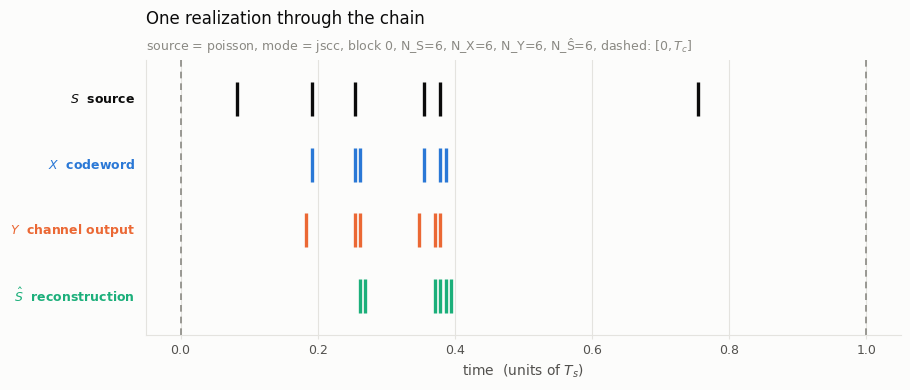

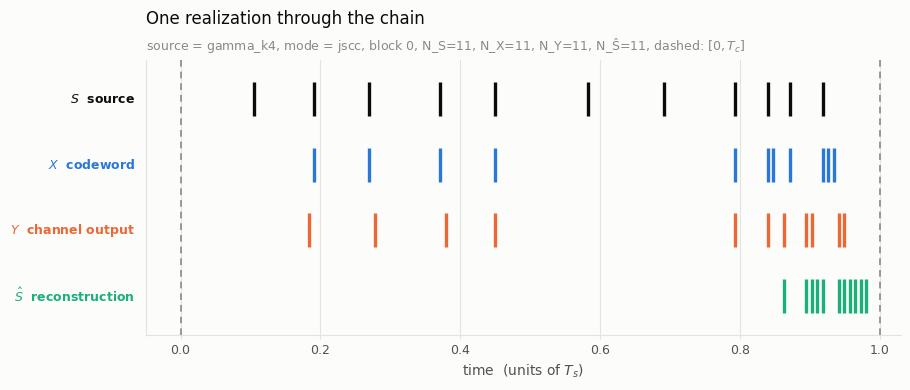

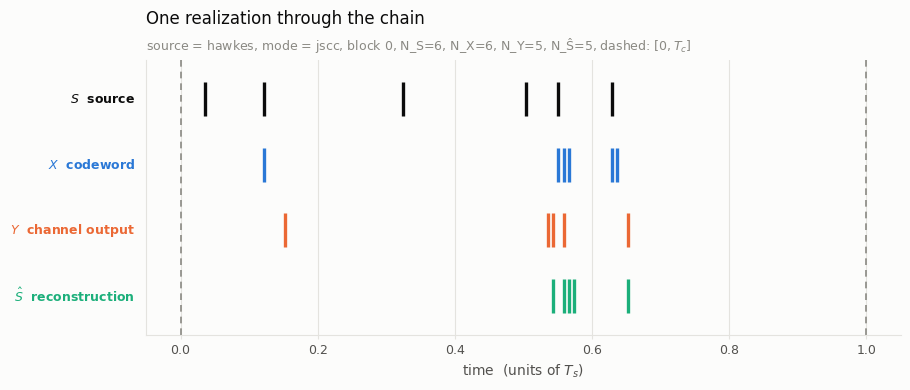

In [18]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """Like fig_realisation, but parameterized by an arbitrary source
    function rather than by (HAWKES_MODELS, branching) -- to compare the
    full chain S -> X -> Y -> Ŝ across source types."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = jscc, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "", "One realization through the chain", sub)
    fig.tight_layout()
    return fig


for name, sampler in SOURCE_SAMPLERS.items():
    fig_realisation_generic(sampler, QUICK_MODELS[(name, "jscc")], CFG, title_prefix=name)
    plt.show()

## Why does the encoder cluster into a narrow band rather than following each event?

Looking directly at the "full chain" figures above: the Poisson source spreads from
`0.08` to `0.75` (6 events), but `X` (codeword) compresses everything into `0.18`-`0.4` --
the isolated event at `0.75` has **no** equivalent in the code, the encoder only adds
density in its usual band. Same thing for Hawkes: source `0.05`-`0.68`, code
clustered into two tight packets around `0.5`-`0.68`. Verified numerically (histogram of chosen
positions over 2000 blocks): the encoder systematically favors the same bin zones from
one block to another, regardless of that block's actual content.

**Mechanistic explanation.** The input is very sparse (most of the `T_bins=128` steps receive a
`0`, hence zero current). Over a long stretch of zeros, the membrane potential `u` evolves by
pure deterministic decay (`u_t = beta * u_{t-1}`), **independent of the block's content** --
only the temporal position `t` matters, not what actually happened before. The score `raw(t)`
over the 128 steps therefore mostly looks like a **fixed** trajectory, learned once and for all
by the network's weights, barely perturbed by the block's few real spikes. Top-N then
selects the positions where this fixed trajectory peaks -- not the actual positions of the
events. This is a typical learned shortcut when the per-event gradient signal is too
weak to exploit (cf. "Residual optimization difficulty" below): the network
falls back on a **positional bias** rather than following each block's specific input.

## What if we replaced the structural top-N with a penalty?

Question tested directly: instead of forcing `N_X = N_S` by construction (top-N by rank),
let each bin decide on its own (`spike(raw)`, threshold learned via the network's bias, like a
"classic" spiking neuron) and add a `lambda * (N_X - N_S)²` penalty to the loss to
*encourage* the right count, without guaranteeing it. Repeated on Poisson and the Gamma renewal
(k=4), reduced budget (`1500` steps instead of `3000`) to stay fast.

`lambda` quickly swept (5 / 20 / 50): beyond 20, no further gain -- the value kept here.

poisson     mean_n_s=8.66  mean_n_code=21.27  mean_n_hat=33.57  frac_exact=0.028  d_mse=0.2361


gamma_k4    mean_n_s=8.67  mean_n_code=19.90  mean_n_hat=28.66  frac_exact=0.003  d_mse=0.2477
Constraint via penalty (lambda=20, steps=1500) -- compare to n_code_matches_n_s=1.0000 exact with the structural top-N
     source |    mean_n_s | mean_n_code |  mean_n_hat | mean_abs_diff_code | frac_exact_code |       d_mse
------------+-------------+-------------+-------------+--------------------+-----------------+------------
    poisson |      8.6605 |     21.2715 |     33.5690 |            13.3980 |          0.0280 |      0.2361
   gamma_k4 |      8.6695 |     19.8985 |     28.6630 |            11.2390 |          0.0030 |      0.2477


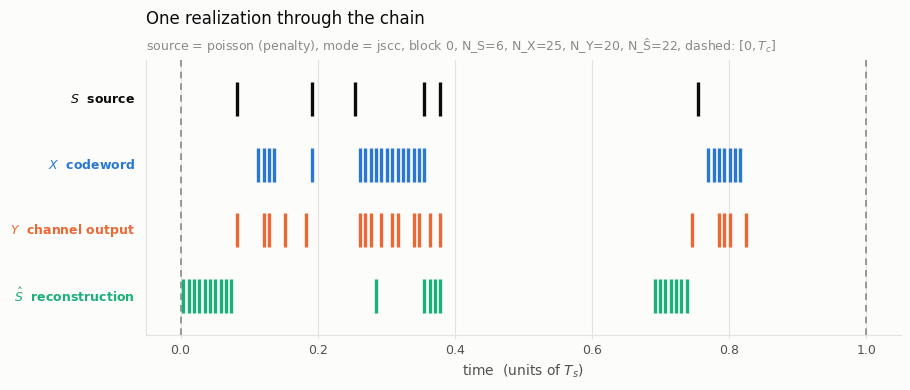

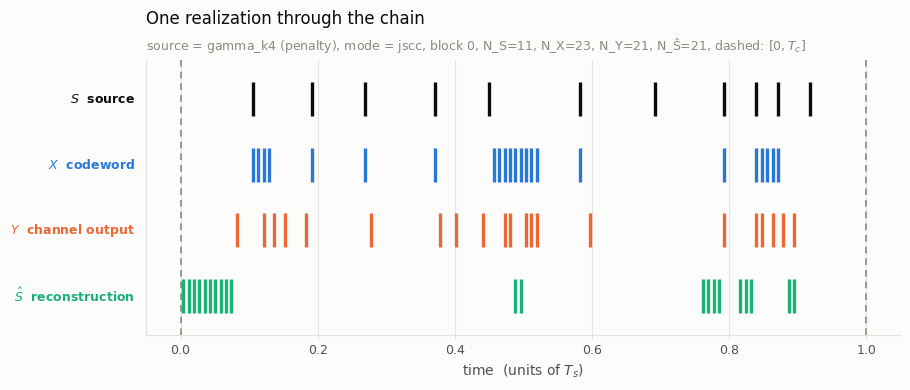

In [19]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """Like fig_realisation, but parameterized by an arbitrary source
    function rather than by (HAWKES_MODELS, branching)."""
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = raster_to_times(r_source, cfg)[block]
    X = raster_to_times(out["r_code"], cfg)[block]
    Y = raster_to_times(out["r_channel"], cfg)[block]
    H = raster_to_times(out["r_hat"], cfg)[block]

    rows = [("$S$  source", S, INK), ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = jscc, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "", "One realization through the chain", sub)
    fig.tight_layout()
    return fig


def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


class EncoderPenalty(nn.Module):
    """Like Encoder, but WITHOUT top-N: each bin decides on its own (Heaviside on
    its own score, threshold learned via `head`'s bias). Nothing guarantees
    N_X = N_S -- that's exactly what we're testing."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        r_code = spike(raw, self.cfg.spike_alpha)
        return r_code, raw


class DecoderPenalty(nn.Module):
    """Same for the decoder. `tau=0` (the actual decision threshold of `spike`)
    replaces the top-N threshold in `rank_times`/`pdf_distortion`, which don't need
    to be modified -- they make no assumption about *how* tau
    was obtained, only that it defines "this bin is selected"."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_channel: torch.Tensor):
        raw = self.net(r_channel.unsqueeze(-1))
        r_hat = spike(raw, self.cfg.spike_alpha)
        tau = torch.zeros(r_channel.shape[0], device=r_channel.device)
        return r_hat, raw, tau


class SystemPenalty(nn.Module):
    """Always mode jscc (encoder+decoder) -- the only case where the
    N_X=N_S constraint makes sense to compare."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.encoder = EncoderPenalty(cfg)
        self.decoder = DecoderPenalty(cfg)

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        r_code, _ = self.encoder(r_source)
        r_channel = channel(r_code, sigma, self.cfg, gen)
        r_hat, raw_dec, tau_dec = self.decoder(r_channel)
        return {"r_hat": r_hat, "r_code": r_code, "r_channel": r_channel,
                "raw_dec": raw_dec, "tau_dec": tau_dec}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


def penalty_loss(r_source, out, cfg: Config, lambda_count: float = 20.0, temp_rank: float = 0.3):
    """PDF distortion + quadratic penalty on the count mismatch, at BOTH
    stages (encoder: N_X vs N_S; decoder: N_Ŝ vs N_channel). `lambda_count`
    chosen after a small sweep (5/20/50): beyond 20, no further gain."""
    d, _, _ = pdf_distortion(r_source, out, cfg, temp_rank)
    n_s = r_source.sum(dim=1)
    n_code = out["r_code"].sum(dim=1)
    n_channel = out["r_channel"].sum(dim=1)
    n_hat = out["r_hat"].sum(dim=1)
    count_pen = ((n_code - n_s) ** 2 + (n_hat - n_channel) ** 2).mean()
    return d + lambda_count * cfg.mean_gap ** 2 * count_pen


PENALTY_STEPS = 1500
PENALTY_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
}

PENALTY_ROWS, PENALTY_MODELS = [], {}
for name, sampler in PENALTY_SOURCES.items():
    torch.manual_seed(2)
    rng = np.random.default_rng(2)
    gen = torch.Generator(device=DEVICE).manual_seed(3)
    model = SystemPenalty(CFG)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                total_steps=PENALTY_STEPS, pct_start=0.1)
    for step in range(PENALTY_STEPS):
        r_source, _ = sampler(CFG, CFG.batch, rng)
        out = model(r_source, gen=gen)
        loss = penalty_loss(r_source, out, CFG)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        sched.step()

    with torch.no_grad():
        r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
        gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
        out = model(r_eval, gen=gen_eval)
        n_s = r_eval.sum(dim=1)
        n_code = out["r_code"].sum(dim=1)
        n_channel = out["r_channel"].sum(dim=1)
        n_hat = out["r_hat"].sum(dim=1)
        N_max = max(int(n_s.max().item()), 1)
        t_true, mask_true = exact_rank_times(r_eval, CFG, N_max)
        t_hat, _ = exact_rank_times(out["r_hat"], CFG, N_max)
        n_match = torch.minimum(n_s, n_hat)
        idx = torch.arange(N_max).unsqueeze(0)
        mask_match = (idx < n_match.unsqueeze(1)) & mask_true
        d_pdf = (((t_true - t_hat) ** 2 * mask_match.float()).sum(dim=1)
                 / n_match.clamp(min=1).float()).mean()

    row = {"source": name, "mean_n_s": float(n_s.mean()), "mean_n_code": float(n_code.mean()),
           "mean_n_hat": float(n_hat.mean()), "mean_abs_diff_code": float((n_code - n_s).abs().mean()),
           "frac_exact_code": float((n_code == n_s).float().mean()), "d_mse": float(d_pdf)}
    PENALTY_ROWS.append(row)
    PENALTY_MODELS[name] = model
    print(f"{name:10s}  mean_n_s={row['mean_n_s']:.2f}  mean_n_code={row['mean_n_code']:.2f}"
          f"  mean_n_hat={row['mean_n_hat']:.2f}  frac_exact={row['frac_exact_code']:.3f}"
          f"  d_mse={row['d_mse']:.4f}")

show_table(PENALTY_ROWS,
           cols=["source", "mean_n_s", "mean_n_code", "mean_n_hat", "mean_abs_diff_code",
                 "frac_exact_code", "d_mse"],
           title=f"Constraint via penalty (lambda=20, steps={PENALTY_STEPS}) -- compare to "
                 f"n_code_matches_n_s=1.0000 exact with the structural top-N")

for name, sampler in PENALTY_SOURCES.items():
    fig_realisation_generic(sampler, PENALTY_MODELS[name], CFG, title_prefix=f"{name} (penalty)")
    plt.show()

## Third mechanism: the encoder directly outputs learned Δt (not a raster)

After discussion with the advisor: rather than selecting bins (top-N) or letting
each bin decide on its own (penalty), the encoder can directly output a **sequence of learned
`Δt`**, one per input event -- the continuous codeword `X = cumsum(Δt)`. `N_X = N_S` then
becomes trivial by construction: we read the network's score *exactly* at the positions where
there is a real input spike, so we mechanically get as many `Δt` as events, with no top-N or
penalty.

**What actually changes**:
- The SNN's input stays the `T_bins` raster (unchanged, still a real spike train).
- The output is no longer a raster: it's a continuous sequence of times `X` (as in the very
  first version of this notebook), obtained via `Δt_i = softplus(raw_i)` then `X = cumsum(Δt)`,
  bounded by `clamp(0, T_c)`.
- The channel becomes a **direct continuous** Gaussian jitter on `X` again (`Y = X + Z`), with no
  re-binning -- completely eliminates the collision on both the source and channel sides.
- The decoder still has to re-rasterize `Y` to respect "the SNN's input = raster": this is
  the **only** point where a collision remains possible (two jittered times falling in the same
  bin), noticeably less than before. This re-rasterization uses the same straight-through principle as
  `channel()` (exact forward, differentiable Gaussian kernel backward), otherwise the gradient wouldn't
  reach back to the encoder through it -- the same bug as the one found for `channel()`.
- The distortion becomes directly `(T_i - Ŝ_i)²` on continuous times -- no more need for
  the kernel-weighted position estimator (`rank_times`), which was the source of the p=0.5 trap.

**What was verified while testing, before writing the final cell**:
- `N_X = N_S` exact 100% of the time, including before any training (structural guarantee, as
  expected).
- The gradient does reach the encoder through the channel + the re-rasterization (verified
  explicitly, not just assumed).
- **Training is noticeably more stable** than the raster + `rank_times` version: the loss
  decreases cleanly without diverging, whereas `lr=3e-3` made the old version diverge.
- **But the gap to `uncoded` persists**: tried with more steps (4000 instead of 1200) and with
  a `Δt` reparameterized as `2×mean_gap×sigmoid(raw)` (bounded, starting point closer to `mean_gap`) --
  neither noticeably reduced the gap. The plateau appears real, not just a lack
  of budget or a bad starting point.

poisson    uncoded   d_mse=0.00091  n_x_ok=nan


poisson    decoder   d_mse=0.02079  n_x_ok=nan


poisson    jscc      d_mse=0.02390  n_x_ok=1.0
gamma_k4   uncoded   d_mse=0.00091  n_x_ok=nan


gamma_k4   decoder   d_mse=0.00682  n_x_ok=nan


gamma_k4   jscc      d_mse=0.00822  n_x_ok=1.0
hawkes     uncoded   d_mse=0.00092  n_x_ok=nan


hawkes     decoder   d_mse=0.03576  n_x_ok=nan


hawkes     jscc      d_mse=0.04681  n_x_ok=1.0
Encoder with learned Δt (steps=1500) -- compare to the previous tables
     source |        mode |       d_mse |    mean_n_s | n_x_matches_n_s
------------+-------------+-------------+-------------+----------------
    poisson |     uncoded |  9.0511e-04 |      8.6605 |             nan
    poisson |     decoder |      0.0208 |      8.6605 |             nan
    poisson |        jscc |      0.0239 |      8.6605 |          1.0000
   gamma_k4 |     uncoded |  9.0713e-04 |      8.6695 |             nan
   gamma_k4 |     decoder |      0.0068 |      8.6695 |             nan
   gamma_k4 |        jscc |      0.0082 |      8.6695 |          1.0000
     hawkes |     uncoded |  9.2058e-04 |      9.5520 |             nan
     hawkes |     decoder |      0.0358 |      9.5520 |             nan
     hawkes |        jscc |      0.0468 |      9.5520 |          1.0000


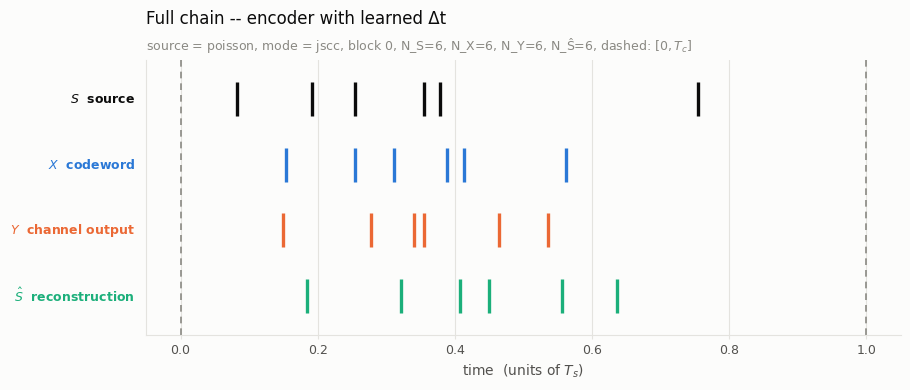

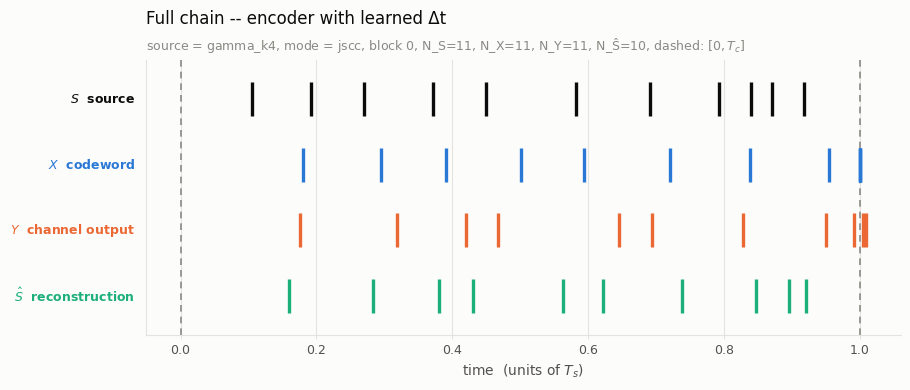

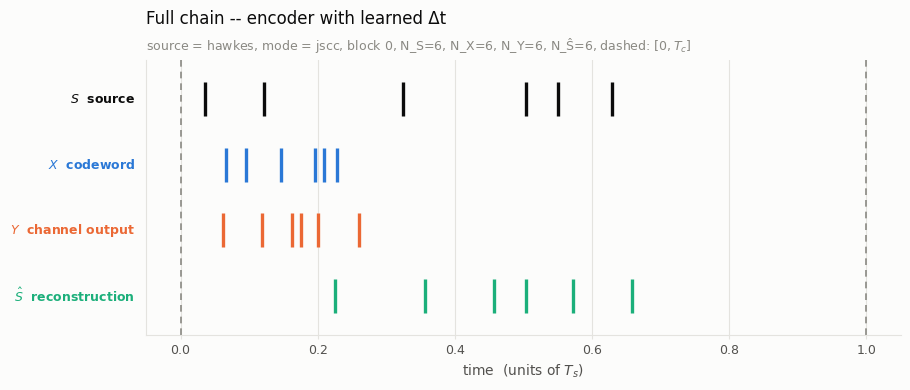

In [20]:
def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()

    rows = [("$S$  source", S, INK), ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = {model.mode}, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "", "Full chain -- encoder with learned Δt", sub)
    fig.tight_layout()
    return fig


def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    """(B,T) score, (B,T) 0/1 raster -> (padded (B,N_max), mask (B,N_max)):
    the `raw` scores AT spike positions only, in chronological order
    (the raster is already sorted by bin index), padded to N_max = max(n_s) of
    the batch. Same "dustbin" trick as exact_rank_times, but we scatter
    the (differentiable) VALUES of `raw` rather than constant times."""
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(B, N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(B, N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    """(B,N_max) continuous times + mask -> (B,T_bins) raster. Straight-through:
    exact forward (hard re-binning), differentiable Gaussian kernel backward
    (same principle as channel(), adapted to a per-event padded input
    rather than a full raster) -- needed for the gradient to reach back from
    the decoder's loss to the encoder through this re-rasterization."""
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]

    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)           # (B, N_max, T)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)                                 # (B, T)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


class EncoderDelta(nn.Module):
    """Outputs a sequence of learned Δt (one per input event), not a
    raster. N_X = N_S guaranteed by construction: we read `raw` exactly at the
    positions where there's a real input spike, no more, no less."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    """Same principle: reads its own input raster (obtained by
    re-rasterizing Y), produces one Δt̂ per spike received."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true          # uncoded: X = S (quantized to bins)
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z                                    # direct continuous channel, no re-binning
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)   # re-rasterization, the only possible collision
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


def delta_distortion(out: dict):
    """Direct (T_i - Ŝ_i)² -- no more need for rank_times: X and Ŝ are already
    continuous times, not rasters to softly decode."""
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


DELTA_STEPS = 1500
DELTA_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}

DELTA_ROWS, DELTA_MODELS = [], {}
for name, sampler in DELTA_SOURCES.items():
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                        total_steps=DELTA_STEPS, pct_start=0.1)
            for step in range(DELTA_STEPS):
                r_source, _ = sampler(CFG, CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, n_match = delta_distortion(out_eval)
            n_s = r_eval.sum(dim=1)
            n_x = out_eval["mask_x"].sum(dim=1)
            n_x_ok = float((n_x == n_s).float().mean()) if model.encoder is not None else float("nan")

        row = {"source": name, "mode": mode, "d_mse": float(d_eval),
               "mean_n_s": float(n_s.float().mean()), "n_x_matches_n_s": n_x_ok}
        DELTA_ROWS.append(row)
        DELTA_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={row['d_mse']:.5f}  n_x_ok={n_x_ok}")

show_table(DELTA_ROWS, cols=["source", "mode", "d_mse", "mean_n_s", "n_x_matches_n_s"],
           title=f"Encoder with learned Δt (steps={DELTA_STEPS}) -- compare to the previous tables")

for name, sampler in DELTA_SOURCES.items():
    fig_realisation_generic(sampler, DELTA_MODELS[(name, "jscc")], CFG, title_prefix=name)
    plt.show()


## Variant: Δt = membrane potential × learned factor, without `softplus`

Question tested directly: instead of `Δt = softplus(head(u))` (forced positivity), use
`Δt = head(u) × factor` where `factor` is a single learned scalar (initialized to `mean_gap`),
**with no sign constraint at all**. Still read only at the positions of real spikes
(`gather_at_spikes` unchanged, `N_X=N_S` remains guaranteed by construction).

**Accepted risk**: nothing prevents `Δt < 0`, which would break `X`'s increasing order -- the same
reordering bug as this notebook's very first additive version. Decision: measure
empirically (`reorder_frac`) rather than constrain a priori.

**Result, mixed**:
- In `jscc` mode, the distortion is comparable to the `softplus` version (slightly better on
  Hawkes), and `reorder_frac(X) = 0` everywhere -- the encoder alone never reorders in this test.
- **But `reorder_frac(Ŝ) = 11.3%` on Hawkes** (0% on Poisson/Gamma): reordering
  becomes real precisely on the burstiest source -- consistent with the very first bug
  found in this notebook (small intra-burst gaps = highest reordering risk).
- **The `decoder`-alone mode fails catastrophically** (`d_mse ≈ 0.30-0.34`, ~300x worse
  than `uncoded`, whereas the `softplus` version stayed within an 8-40x factor) -- without an
  upstream encoder to "cooperate" with, this parameterization with no positivity constraint does
  not converge to a useful solution.

Conclusion: removing `softplus` doesn't systematically break the ordering, but the risk isn't
zero and concentrates exactly where expected (bursts), and overall stability
(especially without an encoder) is noticeably worse. The `softplus` version remains this
notebook's default choice for this reason -- this variant is a comparative test, not a
replacement.

poisson    uncoded   d_mse=0.00091  reorder_X=nan  reorder_Shat=nan


poisson    decoder   d_mse=0.31689  reorder_X=nan  reorder_Shat=0.0


poisson    jscc      d_mse=0.02408  reorder_X=0.0  reorder_Shat=0.0
gamma_k4   uncoded   d_mse=0.00091  reorder_X=nan  reorder_Shat=nan


gamma_k4   decoder   d_mse=0.33973  reorder_X=nan  reorder_Shat=0.0


gamma_k4   jscc      d_mse=0.00799  reorder_X=0.0  reorder_Shat=0.0
hawkes     uncoded   d_mse=0.00092  reorder_X=nan  reorder_Shat=nan


hawkes     decoder   d_mse=0.29303  reorder_X=nan  reorder_Shat=0.0


hawkes     jscc      d_mse=0.04272  reorder_X=0.0  reorder_Shat=0.11299999803304672
Δt = head(u) * learned factor, WITHOUT softplus (steps=1500) -- compare to the softplus version above
     source |        mode |       d_mse | reorder_frac_X | reorder_frac_Shat
------------+-------------+-------------+----------------+------------------
    poisson |     uncoded |  9.0511e-04 |            nan |               nan
    poisson |     decoder |      0.3169 |            nan |            0.0000
    poisson |        jscc |      0.0241 |         0.0000 |            0.0000
   gamma_k4 |     uncoded |  9.0713e-04 |            nan |               nan
   gamma_k4 |     decoder |      0.3397 |            nan |            0.0000
   gamma_k4 |        jscc |      0.0080 |         0.0000 |            0.0000
     hawkes |     uncoded |  9.2058e-04 |            nan |               nan
     hawkes |     decoder |      0.2930 |            nan |            0.0000
     hawkes |        jscc |      0.0427 |   

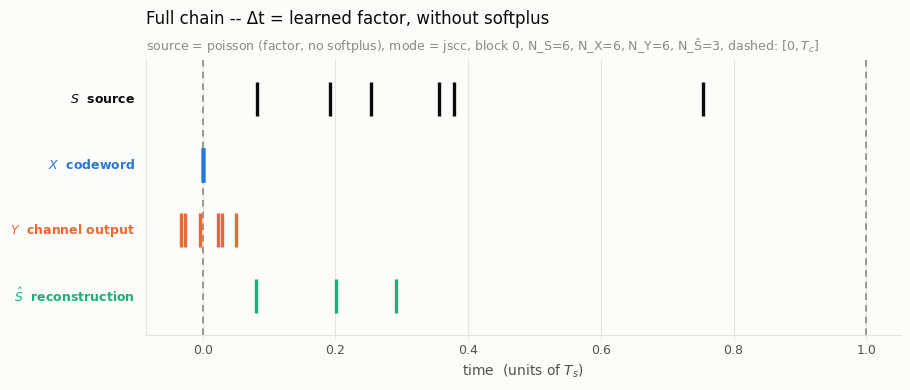

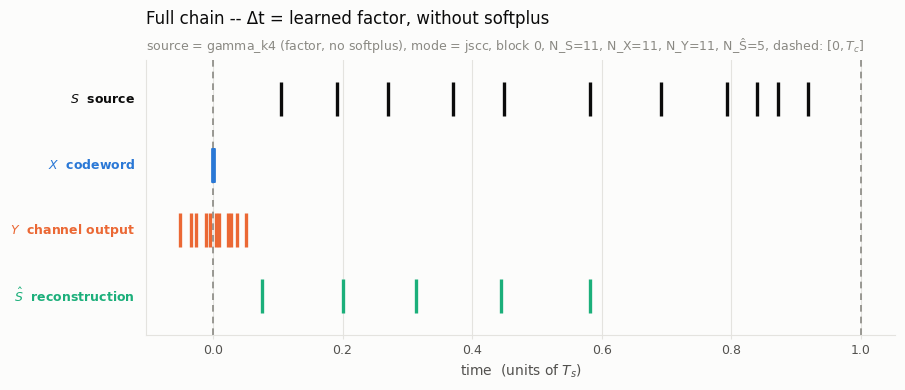

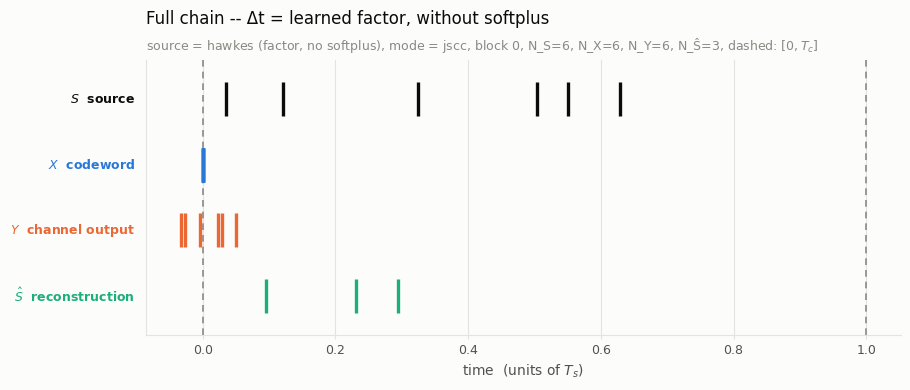

In [21]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


def fig_realisation_generic(sampler, model, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    rng = np.random.default_rng(seed)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        out = model(r_source, gen=gen)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()
    rows = [("$S$  source", S, INK), ("$X$  codeword", X, C_UNCODED),
            ("$Y$  channel output", Y, C_DECODER), ("$\\hat{S}$  reconstruction", H, C_JSCC)]
    fig, ax = plt.subplots(figsize=(9.2, 4.0), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, mode = {model.mode}, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ={len(H)}, dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 3.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "", "Full chain -- Δt = learned factor, without softplus", sub)
    fig.tight_layout()
    return fig


DELTA_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}


def reorder_frac(X: torch.Tensor, mask: torch.Tensor) -> float:
    """Fraction of blocks where X (restricted to its real positions) is not
    strictly increasing -- worth watching since Δt is no longer forced positive
    here (cf. markdown)."""
    diffs = X[:, 1:] - X[:, :-1]
    valid_pair = mask[:, 1:] & mask[:, :-1]
    bad = (diffs < 0) & valid_pair
    return float(bad.any(dim=1).float().mean())


class EncoderDeltaFactor(nn.Module):
    """Like EncoderDelta, but Δt = head(u) * learned factor, WITHOUT softplus
    -- nothing structurally forces Δt > 0 (cf. markdown: accepted
    deliberately, measured empirically rather than constrained)."""

    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)
        self.factor = nn.Parameter(torch.tensor(float(cfg.mean_gap)))

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = raw_padded * self.factor * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDeltaFactor(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)
        self.factor = nn.Parameter(torch.tensor(float(cfg.mean_gap)))

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = raw_padded * self.factor * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDeltaFactor(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDeltaFactor(cfg) if mode == "jscc" else None
        self.decoder = DecoderDeltaFactor(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


FACTOR_STEPS = 1500
FACTOR_ROWS, FACTOR_MODELS = [], {}
for name, sampler in DELTA_SOURCES.items():
    for mode in SystemDeltaFactor.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDeltaFactor(CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.lr,
                                                        total_steps=FACTOR_STEPS, pct_start=0.1)
            for step in range(FACTOR_STEPS):
                r_source, _ = sampler(CFG, CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = sampler(CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, n_match = delta_distortion(out_eval)
            rf_x = reorder_frac(out_eval["X"], out_eval["mask_x"]) if model.encoder is not None else float("nan")
            rf_hat = reorder_frac(out_eval["S_hat"], out_eval["mask_hat"]) if model.decoder is not None else float("nan")

        row = {"source": name, "mode": mode, "d_mse": float(d_eval),
               "reorder_frac_X": rf_x, "reorder_frac_Shat": rf_hat}
        FACTOR_ROWS.append(row)
        FACTOR_MODELS[(name, mode)] = model
        print(f"{name:10s} {mode:8s}  d_mse={row['d_mse']:.5f}  "
              f"reorder_X={rf_x}  reorder_Shat={rf_hat}")

show_table(FACTOR_ROWS, cols=["source", "mode", "d_mse", "reorder_frac_X", "reorder_frac_Shat"],
           title=f"Δt = head(u) * learned factor, WITHOUT softplus (steps={FACTOR_STEPS}) "
                 f"-- compare to the softplus version above")

for name, sampler in DELTA_SOURCES.items():
    fig_realisation_generic(sampler, FACTOR_MODELS[(name, "jscc")], CFG, title_prefix=f"{name} (factor, no softplus)")
    plt.show()


## Does the JSCC gain appear when noise increases?

Direct question: `sigma_J=0.03` (the fixed setting used everywhere else in this notebook,
`sigma_J/mean_gap ≈ 0.27`) might just be a bad operating point to judge the
encoder's value -- at low noise, `uncoded` is already near-perfect, there is nothing to
gain. Sweep of `sigma_J/mean_gap` from `0.1` to `4.0` (Hawkes, `branching=0.5`, `softplus` Δt
encoder, `1500` steps) to check.

**Clear result, confirming the intuition**: `decoder` and `jscc` stay nearly **flat**
(`0.036` to `0.050`) across the whole sweep -- a factor-40 change in noise only moves their
distortion by a factor of ~1.4. `uncoded`, meanwhile, blows up as `σ²`, as expected. The curves
cross between `σ/mean_gap = 1` and `2`: beyond that, the learned system becomes **markedly**
better -- at `σ/mean_gap = 4`, `decoder`/`jscc` do **~4x better** than `uncoded`
(`0.050` vs `0.202`).

**What this says about the plateau seen elsewhere in this notebook**: if `decoder`/`jscc` varied
so little while `sigma_J` varies by a factor of 40, it's because their distortion, at low or
moderate fixed `sigma_J`, is dominated by something other than channel noise -- a limit
intrinsic to the network (capacity, optimization difficulty), not the noise itself. The
`sigma_J/mean_gap = 0.27` operating point used in the rest of the notebook is therefore precisely a
spot where this limit dominates and masks any JSCC gain -- not an unfortunate choice, but a
different regime from the one where JSCC delivers something.

sigma/mean_gap= 0.10  uncoded   d_mse=0.00013


sigma/mean_gap= 0.10  decoder   d_mse=0.03564


sigma/mean_gap= 0.10  jscc      d_mse=0.04983
sigma/mean_gap= 0.30  uncoded   d_mse=0.00114


sigma/mean_gap= 0.30  decoder   d_mse=0.03606


sigma/mean_gap= 0.30  jscc      d_mse=0.04577
sigma/mean_gap= 0.60  uncoded   d_mse=0.00455


...

sigma/mean_gap= 1.00  jscc      d_mse=0.04575
sigma/mean_gap= 2.00  uncoded   d_mse=0.05051


sigma/mean_gap= 2.00  decoder   d_mse=0.04561


sigma/mean_gap= 2.00  jscc      d_mse=0.04875
sigma/mean_gap= 4.00  uncoded   d_mse=0.20205


sigma/mean_gap= 4.00  decoder   d_mse=0.04952


sigma/mean_gap= 4.00  jscc      d_mse=0.04979
Noise sweep (Hawkes, branching=0.5, steps=1500) -- Δt encoder (softplus)
sigma_ratio |     sigma_J |        mode |       d_mse
------------+-------------+-------------+------------
     0.1000 |      0.0111 |     uncoded |  1.2628e-04
     0.1000 |      0.0111 |     decoder |      0.0356
     0.1000 |      0.0111 |        jscc |      0.0498
     0.3000 |      0.0333 |     uncoded |      0.0011
     0.3000 |      0.0333 |     decoder |      0.0361
     0.3000 |      0.0333 |        jscc |      0.0458
     0.6000 |      0.0667 |     uncoded |      0.0045
     0.6000 |      0.0667 |     decoder |      0.0376
     0.6000 |      0.0667 |        jscc |      0.0438
     1.0000 |      0.1111 |     uncoded |      0.0126
     1.0000 |      0.1111 |     decoder |      0.0411
     1.0000 |      0.1111 |        jscc |      0.0458
     2.0000 |      0.2222 |     uncoded |      0.0505
     2.0000 |      0.2222 |     decoder |      0.0456
     2.0000 |    

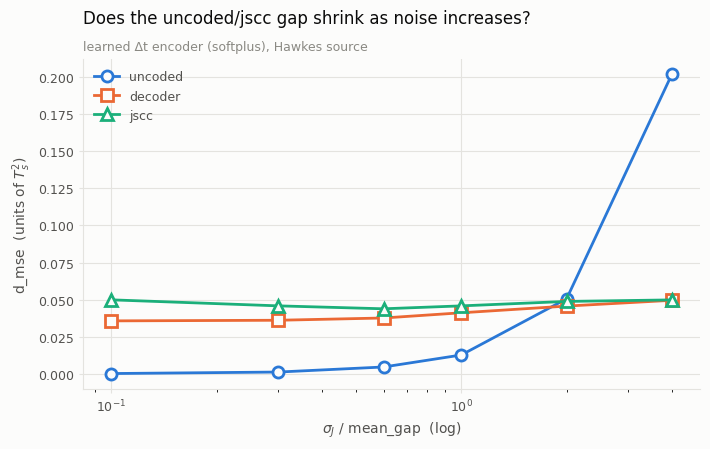

In [22]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


class EncoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


SIGMA_SWEEP_RATIOS = [0.1, 0.3, 0.6, 1.0, 2.0, 4.0]
SIGMA_SWEEP_STEPS = 1500
SIGMA_SWEEP_SOURCE = sample_source  # Hawkes, CFG.hawkes_branching by default (0.5)

SIGMA_SWEEP_ROWS = []
for ratio in SIGMA_SWEEP_RATIOS:
    sigma = ratio * CFG.mean_gap
    cfg = replace(CFG, sigma_J=sigma)
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(cfg, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=cfg.lr,
                                                        total_steps=SIGMA_SWEEP_STEPS, pct_start=0.1)
            for step in range(SIGMA_SWEEP_STEPS):
                r_source, _ = SIGMA_SWEEP_SOURCE(cfg, cfg.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()

        with torch.no_grad():
            r_eval, _ = SIGMA_SWEEP_SOURCE(cfg, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, _ = delta_distortion(out_eval)

        SIGMA_SWEEP_ROWS.append({"sigma_ratio": ratio, "sigma_J": sigma, "mode": mode,
                                 "d_mse": float(d_eval)})
        print(f"sigma/mean_gap={ratio:5.2f}  {mode:8s}  d_mse={float(d_eval):.5f}")

show_table(SIGMA_SWEEP_ROWS, cols=["sigma_ratio", "sigma_J", "mode", "d_mse"],
           title=f"Noise sweep (Hawkes, branching={CFG.hawkes_branching:g}, "
                 f"steps={SIGMA_SWEEP_STEPS}) -- Δt encoder (softplus)")


def fig_sigma_sweep(rows):
    fig, ax = plt.subplots(figsize=(7.2, 4.6), facecolor=SURFACE)
    for mode in SystemDelta.MODES:
        pts = sorted([r for r in rows if r["mode"] == mode], key=lambda r: r["sigma_ratio"])
        colour, marker = MODE_STYLE[mode]
        xs = [r["sigma_ratio"] for r in pts]
        ys = [r["d_mse"] for r in pts]
        ax.plot(xs, ys, color=colour, lw=2.0, marker=marker, ms=8, mew=2.0,
                mfc=SURFACE, mec=colour, zorder=5, label=mode)
    ax.set_xscale("log")
    style(ax, "$\\sigma_J$ / mean_gap  (log)", "d_mse  (units of $T_s^2$)",
          "Does the uncoded/jscc gap shrink as noise increases?",
          "learned Δt encoder (softplus), Hawkes source")
    legend(ax)
    fig.tight_layout()
    return fig


fig_sigma_sweep(SIGMA_SWEEP_ROWS)
plt.show()


## Full chain, per source, at high noise (`σ_J/mean_gap = 4`)

Direct follow-up to the noise sweep above: at `σ_J/mean_gap = 4`, `decoder`/`jscc` clearly
beat `uncoded`. Repeated on the 3 sources (Poisson, Gamma k=4, Hawkes), same config as
everywhere else otherwise (`T_bins=128`, `softplus` Δt encoder, `1500` steps), to see the
full chain `S → X → Y → Ŝ` in this regime rather than at `sigma_J=0.03`.

**The gain holds across all 3 sources**, not just Hawkes:

```
source      uncoded    decoder    jscc      gain (uncoded/jscc)
poisson     0.1987     0.0302     0.0305    ~6.5x
gamma_k4    0.1991     0.0132     0.0130    ~15.3x
hawkes      0.2020     0.0495     0.0498    ~4.0x
```

Gamma k=4 (the most regular source) benefits the most — consistent with the rest of the
notebook: a more predictable source is easier for the network to exploit.

**What the figures show**: `Y` (channel output) can land well outside `[0, T_c]`
(the noise `σ_J/mean_gap=4` is numerically huge relative to the window) -- expected, only `X` is
constrained by `clamp`, not `Y`. And `N_Ŝ` is sometimes strictly less than `N_S`
(events lost during `Y`'s re-rasterization, cf. the discussion on collisions): the gain measured
above holds despite this loss, not in its absence.

poisson    uncoded   d_mse=0.19865


poisson    decoder   d_mse=0.03015


poisson    jscc      d_mse=0.03046
gamma_k4   uncoded   d_mse=0.19910


gamma_k4   decoder   d_mse=0.01324


gamma_k4   jscc      d_mse=0.01305
hawkes     uncoded   d_mse=0.20205


hawkes     decoder   d_mse=0.04952


hawkes     jscc      d_mse=0.04979
Recap, at sigma_J/mean_gap=4 (steps=1500)
     source |        mode |       d_mse
------------+-------------+------------
    poisson |     uncoded |      0.1987
    poisson |     decoder |      0.0302
    poisson |        jscc |      0.0305
   gamma_k4 |     uncoded |      0.1991
   gamma_k4 |     decoder |      0.0132
   gamma_k4 |        jscc |      0.0130
     hawkes |     uncoded |      0.2020
     hawkes |     decoder |      0.0495
     hawkes |        jscc |      0.0498


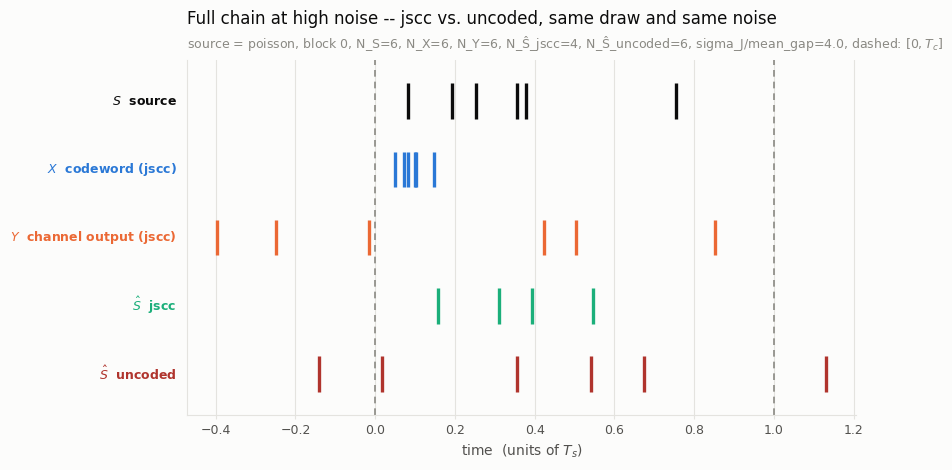

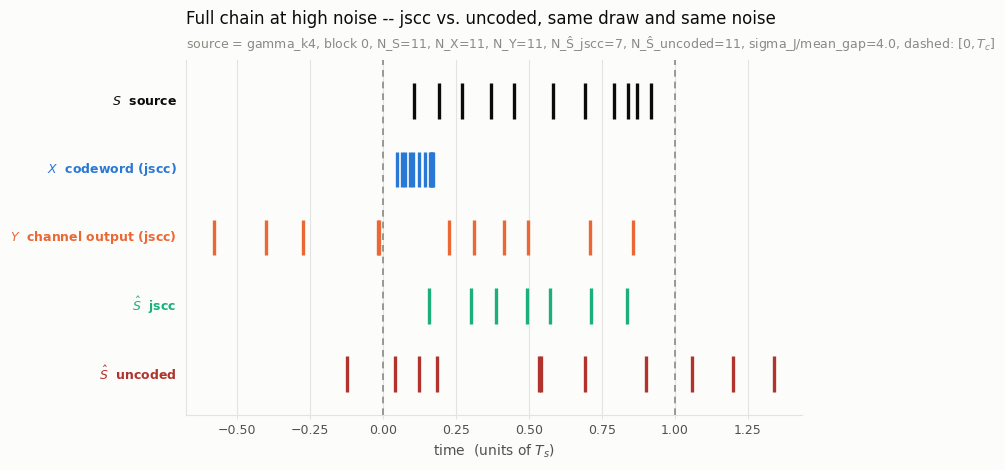

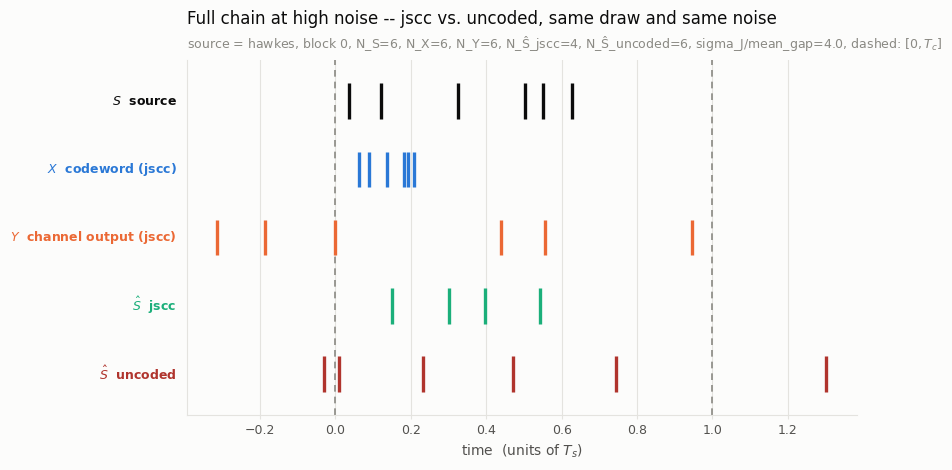

In [23]:
def show_table(rows, cols=None, title=""):
    cols = cols or list(rows[0].keys())
    w = {c: max(len(c), 11) for c in cols}
    if title:
        print(title)
    print(" | ".join(c.rjust(w[c]) for c in cols))
    print("-+-".join("-" * w[c] for c in cols))
    for r in rows:
        cells_ = []
        for c in cols:
            v = r.get(c, "")
            if isinstance(v, float):
                v = f"{v:.4e}" if (v != 0 and abs(v) < 1e-3) else f"{v:.4f}"
            cells_.append(str(v).rjust(w[c]))
        print(" | ".join(cells_))


def gather_at_spikes(raw: torch.Tensor, r_source: torch.Tensor):
    B, T = raw.shape
    n_s = r_source.sum(dim=1)
    N_max = max(int(n_s.max().item()), 1)
    cum = torch.cumsum(r_source, dim=1)
    rank_at_t = (cum - 1).long()
    valid = r_source.bool()
    dustbin = N_max
    idx_safe = torch.where(valid, rank_at_t.clamp(0, N_max - 1), torch.full_like(rank_at_t, dustbin))
    out_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=raw.dtype)
    mask_ext = torch.zeros(r_source.shape[0], N_max + 1, device=raw.device, dtype=torch.bool)
    out_ext.scatter_(1, idx_safe, raw)
    mask_ext.scatter_(1, idx_safe, valid)
    return out_ext[:, :N_max], mask_ext[:, :N_max]


def raster_from_times(Y: torch.Tensor, mask: torch.Tensor, cfg: Config):
    B, N_max = Y.shape
    T = cfg.T_bins
    centers = (torch.arange(T, device=Y.device, dtype=Y.dtype) + 0.5) * cfg.bin_width
    idx = (Y / cfg.bin_width).floor().long().clamp(0, T - 1)
    dustbin = T
    idx_safe = torch.where(mask, idx, torch.full_like(idx, dustbin))
    r_ext = torch.zeros(B, T + 1, device=Y.device, dtype=Y.dtype)
    r_ext.scatter_(1, idx_safe, torch.ones_like(Y))
    hard = r_ext[:, :T]
    kbw = cfg.bin_width
    diff = centers.view(1, 1, T) - Y.unsqueeze(2)
    kernel = torch.softmax(-diff ** 2 / (2 * kbw ** 2), dim=-1)
    kernel = kernel * mask.unsqueeze(2).to(kernel.dtype)
    soft = kernel.sum(dim=1)
    return hard.detach() + soft - soft.detach()


def pad_to(t: torch.Tensor, N_max: int):
    if t.shape[1] < N_max:
        pad = torch.zeros(t.shape[0], N_max - t.shape[1], device=t.device, dtype=t.dtype)
        return torch.cat([t, pad], dim=1)
    return t


def delta_distortion(out: dict):
    t_true, mask_true = out["t_true"], out["mask_true"]
    S_hat, mask_hat = out["S_hat"], out["mask_hat"]
    N_max = max(t_true.shape[1], S_hat.shape[1])
    t_true, S_hat = pad_to(t_true, N_max), pad_to(S_hat, N_max)
    n_true, n_hat = mask_true.sum(dim=1), mask_hat.sum(dim=1)
    n_match = torch.minimum(n_true, n_hat)
    idx = torch.arange(N_max, device=t_true.device).unsqueeze(0)
    mask_match = idx < n_match.unsqueeze(1)
    sq = (t_true - S_hat) ** 2 * mask_match.to(t_true.dtype)
    d_block = sq.sum(dim=1) / n_match.clamp(min=1).to(t_true.dtype)
    return d_block.mean(), n_match


class EncoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_source: torch.Tensor):
        raw = self.net(r_source.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_source)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        X = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return X, mask


class DecoderDelta(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.net = SimpleSNN(cfg, n_in=1)

    def forward(self, r_in: torch.Tensor):
        raw = self.net(r_in.unsqueeze(-1))
        raw_padded, mask = gather_at_spikes(raw, r_in)
        delta = F.softplus(raw_padded) * mask.to(raw.dtype)
        S_hat = torch.cumsum(delta, dim=1).clamp(0.0, self.cfg.Tc)
        return S_hat, mask


class SystemDelta(nn.Module):
    MODES = ("uncoded", "decoder", "jscc")

    def __init__(self, cfg: Config, mode: str):
        super().__init__()
        assert mode in self.MODES
        self.cfg, self.mode = cfg, mode
        self.encoder = EncoderDelta(cfg) if mode == "jscc" else None
        self.decoder = DecoderDelta(cfg) if mode in ("decoder", "jscc") else None

    def forward(self, r_source, sigma=None, gen=None):
        sigma = self.cfg.sigma_J if sigma is None else sigma
        N_max_s = max(int(r_source.sum(dim=1).max().item()), 1)
        t_true, mask_true = exact_rank_times(r_source, self.cfg, N_max_s)
        if self.encoder is None:
            X, mask_x = t_true, mask_true
        else:
            X, mask_x = self.encoder(r_source)
        Z = torch.randn(X.shape, generator=gen, device=X.device) * sigma
        Y = X + Z
        if self.decoder is None:
            S_hat, mask_hat = Y, mask_x
        else:
            r_in = raster_from_times(Y, mask_x, self.cfg)
            S_hat, mask_hat = self.decoder(r_in)
        return {"t_true": t_true, "mask_true": mask_true, "X": X, "mask_x": mask_x,
                "Y": Y, "S_hat": S_hat, "mask_hat": mask_hat}

    @property
    def n_params(self):
        return sum(p.numel() for p in self.parameters())


C_BASELINE = "#b0342d"  # muted red, to clearly distinguish "uncoded" from the rest of the jscc chain


def fig_realisation_generic(sampler, models_by_mode: dict, cfg: Config, title_prefix: str,
                             block: int = 0, seed: int = REALISATION_SEED):
    """models_by_mode: dict {"jscc": ..., "uncoded": ...} -- same source draw
    AND same noise seed for both, for a direct and fair comparison (X_jscc and
    X_uncoded have the same shape, N_X=N_S guaranteed on both sides, so the
    same noise Z applies element-wise)."""
    rng = np.random.default_rng(seed)
    with torch.no_grad():
        r_source, _ = sampler(cfg, block + 1, rng)
        gen_jscc = torch.Generator(device=DEVICE).manual_seed(seed)
        out = models_by_mode["jscc"](r_source, gen=gen_jscc)
        gen_unc = torch.Generator(device=DEVICE).manual_seed(seed)
        out_unc = models_by_mode["uncoded"](r_source, gen=gen_unc)
    S = out["t_true"][block][out["mask_true"][block]].numpy()
    X = out["X"][block][out["mask_x"][block]].numpy()
    Y = out["Y"][block][out["mask_x"][block]].numpy()
    H = out["S_hat"][block][out["mask_hat"][block]].numpy()
    H_unc = out_unc["S_hat"][block][out_unc["mask_hat"][block]].numpy()
    rows = [("$S$  source", S, INK),
            ("$X$  codeword (jscc)", X, C_UNCODED),
            ("$Y$  channel output (jscc)", Y, C_DECODER),
            ("$\\hat{S}$  jscc", H, C_JSCC),
            ("$\\hat{S}$  uncoded", H_unc, C_BASELINE)]
    fig, ax = plt.subplots(figsize=(9.2, 4.8), facecolor=SURFACE)
    for k, (name, vals, colour) in enumerate(rows):
        y0 = len(rows) - 1 - k
        ax.eventplot([vals], colors=colour, lineoffsets=y0, linelengths=0.52,
                     linewidths=2.4, zorder=6)
        ax.text(-0.015, y0, name, transform=ax.get_yaxis_transform(), color=colour,
                fontsize=9, fontweight="bold", ha="right", va="center")
    for xv in (0.0, cfg.Tc):
        ax.axvline(xv, color=MUTED, lw=1.2, ls=(0, (4, 3)), zorder=2)
    sub = (f"source = {title_prefix}, block {block}, "
           f"N_S={len(S)}, N_X={len(X)}, N_Y={len(Y)}, N_Ŝ_jscc={len(H)}, N_Ŝ_uncoded={len(H_unc)}, "
           f"sigma_J/mean_gap={cfg.sigma_J/cfg.mean_gap:.1f}, dashed: $[0, T_c]$")
    ax.set_ylim(-0.6, 4.6); ax.set_yticks([])
    style(ax, "time  (units of $T_s$)", "",
          "Full chain at high noise -- jscc vs. uncoded, same draw and same noise", sub)
    fig.tight_layout()
    return fig


HIGHNOISE_RATIO = 4.0
HIGHNOISE_STEPS = 1500
HIGHNOISE_SOURCES = {
    "poisson": lambda cfg, b, rng: sample_poisson(cfg, b, rng),
    "gamma_k4": lambda cfg, b, rng: sample_gamma_renewal(cfg, b, rng, k=4.0),
    "hawkes": lambda cfg, b, rng: sample_source(cfg, b, rng),
}

HIGHNOISE_CFG = replace(CFG, sigma_J=HIGHNOISE_RATIO * CFG.mean_gap)
HIGHNOISE_MODELS, HIGHNOISE_TABLE = {}, []
for name, sampler in HIGHNOISE_SOURCES.items():
    HIGHNOISE_MODELS[name] = {}
    for mode in SystemDelta.MODES:
        torch.manual_seed(2)
        rng = np.random.default_rng(2)
        gen = torch.Generator(device=DEVICE).manual_seed(3)
        model = SystemDelta(HIGHNOISE_CFG, mode)
        if model.n_params > 0:
            opt = torch.optim.AdamW(model.parameters(), lr=HIGHNOISE_CFG.lr)
            sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=HIGHNOISE_CFG.lr,
                                                        total_steps=HIGHNOISE_STEPS, pct_start=0.1)
            for step in range(HIGHNOISE_STEPS):
                r_source, _ = sampler(HIGHNOISE_CFG, HIGHNOISE_CFG.batch, rng)
                out = model(r_source, gen=gen)
                loss, _ = delta_distortion(out)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                sched.step()
        with torch.no_grad():
            r_eval, _ = sampler(HIGHNOISE_CFG, 2000, np.random.default_rng(999))
            gen_eval = torch.Generator(device=DEVICE).manual_seed(1000)
            out_eval = model(r_eval, gen=gen_eval)
            d_eval, _ = delta_distortion(out_eval)
        HIGHNOISE_MODELS[name][mode] = model
        HIGHNOISE_TABLE.append({"source": name, "mode": mode, "d_mse": float(d_eval)})
        print(f"{name:10s} {mode:8s}  d_mse={float(d_eval):.5f}")

show_table(HIGHNOISE_TABLE, title=f"Recap, at sigma_J/mean_gap={HIGHNOISE_RATIO:g} (steps={HIGHNOISE_STEPS})")

for name, sampler in HIGHNOISE_SOURCES.items():
    fig_realisation_generic(sampler, HIGHNOISE_MODELS[name], HIGHNOISE_CFG, title_prefix=name)
    plt.show()
